<a href="https://colab.research.google.com/github/jujutupaki/Traffic-Congestion-Prediction-using-XGBoost-RF-and-LSTM/blob/main/GPU_Data_Modelling_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Libraries**

In [ ]:
#Libraries
from google.colab import files
import pandas as pd
import glob
import os
import numpy as np
from sklearn.cluster import KMeans
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

**Load Dataset**

In [ ]:
#Google Drive
from google.colab import drive
drive.mount('/content/drive')

#Load the dataset
dataset_df = pd.read_csv('/content/drive/MyDrive/Thesis/Dataset/Combined_Traffic_Weather_Data(Removed_Cyclical_Encoding).csv')

Mounted at /content/drive


**Cross Validation Split**

In [ ]:
#Separate final test set from train-validation split
dataset_df['10_Minutes_Interval'] = pd.to_datetime(dataset_df['10_Minutes_Interval'])
train_val = dataset_df[(dataset_df['10_Minutes_Interval'] >= pd.Timestamp('2025-01-01 00:00:00')) & (dataset_df['10_Minutes_Interval'] <= '2025-11-23 11:50:00')].reset_index(drop=True)
#train_val.head()
#train_val.tail()
test = dataset_df[(dataset_df['10_Minutes_Interval'] >= pd.Timestamp('2025-11-24 00:00:00'))].reset_index(drop=True)
#test.head()
test.tail()

,10_Minutes_Interval,Driving Direction,Vehicle_Count,Simulated Traffic Level,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),precipitation (mm),rain (mm),...,vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_gusts_10m (km/h),Minute,Hour,Day,DayOfWeek,Week,Month,DayOfYear
4027,2025-12-07 23:30:00,1,55.0,1,15.8,89,14.0,16.9,0.0,0.0,...,0.2,1.6,13.3,30,23,7,6,49,12,341
4028,2025-12-07 23:40:00,0,9.0,0,15.8,89,14.0,16.9,0.0,0.0,...,0.2,1.6,13.3,40,23,7,6,49,12,341
4029,2025-12-07 23:40:00,1,64.0,1,15.8,89,14.0,16.9,0.0,0.0,...,0.2,1.6,13.3,40,23,7,6,49,12,341
4030,2025-12-07 23:50:00,0,18.0,1,15.8,89,14.0,16.9,0.0,0.0,...,0.2,1.6,13.3,50,23,7,6,49,12,341
4031,2025-12-07 23:50:00,1,54.0,1,15.8,89,14.0,16.9,0.0,0.0,...,0.2,1.6,13.3,50,23,7,6,49,12,341


In [ ]:
X = train_val.drop(columns=['Simulated Traffic Level', '10_Minutes_Interval','Vehicle_Count'])
y = train_val['Simulated Traffic Level']
X.tail()

,Driving Direction,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),precipitation (mm),rain (mm),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_temperature_28_to_100cm (°C),...,vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_gusts_10m (km/h),Minute,Hour,Day,DayOfWeek,Week,Month,DayOfYear
93447,1,22.5,60,14.4,24.3,0.2,0.2,21.4,18.3,18.7,...,1.09,5.3,31.7,30,11,23,6,47,11,327
93448,0,22.5,60,14.4,24.3,0.2,0.2,21.4,18.3,18.7,...,1.09,5.3,31.7,40,11,23,6,47,11,327
93449,1,22.5,60,14.4,24.3,0.2,0.2,21.4,18.3,18.7,...,1.09,5.3,31.7,40,11,23,6,47,11,327
93450,0,22.5,60,14.4,24.3,0.2,0.2,21.4,18.3,18.7,...,1.09,5.3,31.7,50,11,23,6,47,11,327
93451,1,22.5,60,14.4,24.3,0.2,0.2,21.4,18.3,18.7,...,1.09,5.3,31.7,50,11,23,6,47,11,327


In [ ]:
X_test = test.drop(columns=['Simulated Traffic Level', '10_Minutes_Interval','Vehicle_Count'])
y_test = test['Simulated Traffic Level']
X_test.tail()

,Driving Direction,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),precipitation (mm),rain (mm),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_temperature_28_to_100cm (°C),...,vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_gusts_10m (km/h),Minute,Hour,Day,DayOfWeek,Week,Month,DayOfYear
4027,1,15.8,89,14.0,16.9,0.0,0.0,16.8,17.8,18.0,...,0.2,1.6,13.3,30,23,7,6,49,12,341
4028,0,15.8,89,14.0,16.9,0.0,0.0,16.8,17.8,18.0,...,0.2,1.6,13.3,40,23,7,6,49,12,341
4029,1,15.8,89,14.0,16.9,0.0,0.0,16.8,17.8,18.0,...,0.2,1.6,13.3,40,23,7,6,49,12,341
4030,0,15.8,89,14.0,16.9,0.0,0.0,16.8,17.8,18.0,...,0.2,1.6,13.3,50,23,7,6,49,12,341
4031,1,15.8,89,14.0,16.9,0.0,0.0,16.8,17.8,18.0,...,0.2,1.6,13.3,50,23,7,6,49,12,341


In [ ]:
print(f"Train/Val pool : {X.shape[0]:,} rows | {X.shape[1]} features")
print(f"Final test set : {X_test.shape[0]:,} rows")
print(f"\nFeature columns:\n{X.columns.tolist()}")
print(f"\nClass distribution in train/val:\n{y.value_counts(normalize=True).round(3)}")

Train/Val pool : 93,452 rows | 30 features
Final test set : 4,032 rows

Feature columns:
['Driving Direction', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'dew_point_2m (°C)', 'apparent_temperature (°C)', 'precipitation (mm)', 'rain (mm)', 'soil_temperature_0_to_7cm (°C)', 'soil_temperature_7_to_28cm (°C)', 'soil_temperature_28_to_100cm (°C)', 'soil_temperature_100_to_255cm (°C)', 'soil_moisture_0_to_7cm (m³/m³)', 'soil_moisture_7_to_28cm (m³/m³)', 'soil_moisture_28_to_100cm (m³/m³)', 'soil_moisture_100_to_255cm (m³/m³)', 'surface_pressure (hPa)', 'cloud_cover (%)', 'cloud_cover_low (%)', 'cloud_cover_mid (%)', 'cloud_cover_high (%)', 'vapour_pressure_deficit (kPa)', 'wind_speed_10m (km/h)', 'wind_gusts_10m (km/h)', 'Minute', 'Hour', 'Day', 'DayOfWeek', 'Week', 'Month', 'DayOfYear']

Class distribution in train/val:
Simulated Traffic Level
1    0.431
0    0.313
2    0.256
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import TimeSeriesSplit

#Splitting data using Time-Series-Split
tscv = TimeSeriesSplit(n_splits=3, gap=6)
for i, (train_index, test_index) in enumerate(tscv.split(train_val)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

Fold 0:
  Train: index=[    0     1     2 ... 23354 23355 23356]
  Test:  index=[23363 23364 23365 ... 46723 46724 46725]
Fold 1:
  Train: index=[    0     1     2 ... 46717 46718 46719]
  Test:  index=[46726 46727 46728 ... 70086 70087 70088]
Fold 2:
  Train: index=[    0     1     2 ... 70080 70081 70082]
  Test:  index=[70089 70090 70091 ... 93449 93450 93451]


In [ ]:
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score,
                              classification_report)

def get_classification_metrics(y_true, y_pred, model_name):
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*50}")
    print(f"  {model_name} — CLASSIFICATION METRICS")
    print(f"{'='*50}")
    print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"\nDetailed Report:")
    print(classification_report(y_true, y_pred,
                                 target_names=['Low','Medium','High'],
                                 zero_division=0))

    return {
        'Model': model_name,
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1 Score': round(f1, 4)
    }

# @title Function for Evaluation Metrics
def evaluate_metrics(y_true, y_pred):

    metrics = {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1 Score' : f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }
    return metrics

def average_metrics(all_metrics):
    avg = {
        'Accuracy' : np.mean([m['Accuracy'] for m in all_metrics]),
        'Precision': np.mean([m['Precision'] for m in all_metrics]),
        'Recall'   : np.mean([m['Recall'] for m in all_metrics]),
        'F1 Score' : np.mean([m['F1 Score'] for m in all_metrics]),
    }
    return avg

# **Individual Model Training**

# *XGBoost*

In [ ]:
import numpy as np
import pandas as pd

def evaluate_metrics(y_true, y_pred):

    metrics = {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1 Score' : f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }
    return metrics

def average_metrics(all_metrics):
    avg = {
        'Accuracy' : np.mean([m['Accuracy'] for m in all_metrics]),
        'Precision': np.mean([m['Precision'] for m in all_metrics]),
        'Recall'   : np.mean([m['Recall'] for m in all_metrics]),
        'F1 Score' : np.mean([m['F1 Score'] for m in all_metrics]),
    }
    return avg

# @title XGBoost Model and Evaluation using Train-Test Data
xgb_all_metrics = []
xgb_all_importances = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(train_val)):

    xgb_model = XGBClassifier(
            objective        = 'multi:softmax',  # multiclass classification — discrete labels
            num_class        = 3,                # Light=0, Moderate=1, Heavy=2
            eval_metric      = 'mlogloss',       # standard multiclass loss metric
            n_estimators     = 100,              # baseline tree count — conservative starting point
            max_depth        = 4,                # shallow trees reduce overfitting on baseline
            learning_rate    = 0.1,              # standard baseline learning rate
            subsample        = 0.8,              # row subsampling — mild regularization
            colsample_bytree = 0.8,              # feature subsampling — mild regularization
            random_state     = 42,
            n_jobs           = -1,
    )

    X_train = X.loc[train_idx]
    y_train = y.loc[train_idx]

    X_val = X.loc[val_idx]
    y_val = y.loc[val_idx]

    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_val)

    metrics = evaluate_metrics(y_val, y_pred)
    xgb_all_metrics.append(metrics)

    print(f"Fold {fold}: {metrics}")

    xgb_importance_fold = pd.Series(
        xgb_model.feature_importances_,
        index=X.columns,
        name=f'Fold_{fold+1}'
    )
    xgb_all_importances.append(xgb_importance_fold)

avg_results = average_metrics(xgb_all_metrics)

print("\nAverage Metrics Across All Folds:")
for k, v in avg_results.items():
    print(f"{k}: {v:.4f}")

Fold 0: {'Accuracy': 0.6571501947523862, 'Precision': 0.6709925302251022, 'Recall': 0.6571501947523862, 'F1 Score': 0.6513592398903413}
Fold 1: {'Accuracy': 0.6303556906219235, 'Precision': 0.6890545209009891, 'Recall': 0.6303556906219235, 'F1 Score': 0.620046854289483}
Fold 2: {'Accuracy': 0.6952874202799298, 'Precision': 0.7104751953638596, 'Recall': 0.6952874202799298, 'F1 Score': 0.6981427372316344}

Average Metrics Across All Folds:
Accuracy: 0.6609
Precision: 0.6902
Recall: 0.6609
F1 Score: 0.6565


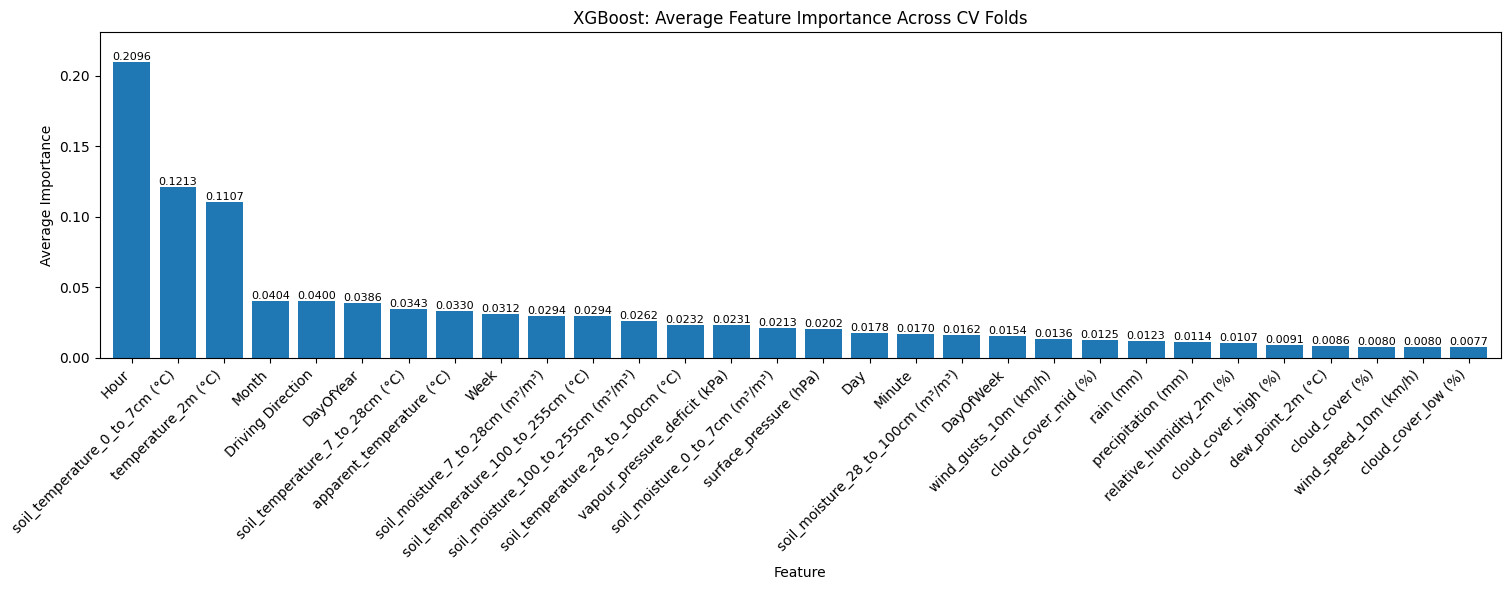

In [ ]:
# @title Feature Importance using Built-in XGBoost Importance

xgb_importance_df = pd.concat(xgb_all_importances, axis=1)
xgb_avg_importance = xgb_importance_df.mean(axis=1)

# Combine into one DataFrame
xgb_avg_importance_df = pd.DataFrame({
    'Feature': xgb_avg_importance.index,
    'Importance': xgb_avg_importance.values
})

# Sort for plotting (descending works better for vertical bars)
plot_df = xgb_avg_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(max(10, len(plot_df) * 0.5), 6))

bars = plt.bar(plot_df['Feature'], plot_df['Importance'])

plt.xlabel("Feature")
plt.ylabel("Average Importance")
plt.title("XGBoost: Average Feature Importance Across CV Folds")

# Rotate x labels if many features
plt.xticks(rotation=45, ha='right')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.4f}',   # format as needed
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.margins(x=0.01, y=0.1)
plt.show()

# *Random Forest*

In [ ]:
# @title Random Forest Model and Evaluation using Cross Validation
rf_all_metrics = []
rf_all_importances = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(train_val)):

    rf_model = RandomForestClassifier(
            n_estimators  = 100,        # baseline tree count — same as XGBoost baseline
            max_depth     = None,       # unconstrained depth is RF's standard default;
            max_features  = 'sqrt',     # sqrt(n_features) per split — RF standard for classification
            min_samples_split = 10,     # minimum samples required to split a node — mild regularization
            min_samples_leaf  = 5,      # minimum samples required at a leaf — reduces overfitting
            class_weight  = 'balanced', # adjusts weights inversely proportional to class frequency
            random_state  = 42,
            n_jobs        = -1,
    )

    X_train = X.loc[train_idx]
    y_train = y.loc[train_idx]

    X_val = X.loc[val_idx]
    y_val = y.loc[val_idx]

    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_val)

    metrics = evaluate_metrics(y_val, y_pred)
    rf_all_metrics.append(metrics)

    print(f"Fold {fold}: {metrics}")

    rf_importance_fold = pd.Series(
        rf_model.feature_importances_,
        index=X.columns,
        name=f'Fold_{fold+1}'
    )
    rf_all_importances.append(rf_importance_fold)

avg_results = average_metrics(rf_all_metrics)

print("\nAverage Metrics Across All Folds:")
for k, v in avg_results.items():
    print(f"{k}: {v:.4f}")


Fold 0: {'Accuracy': 0.6035611864914608, 'Precision': 0.6361381694732214, 'Recall': 0.6035611864914608, 'F1 Score': 0.6123049021635005}
Fold 1: {'Accuracy': 0.6372897316269315, 'Precision': 0.6617455889306465, 'Recall': 0.6372897316269315, 'F1 Score': 0.6388661680532244}
Fold 2: {'Accuracy': 0.6933612977785387, 'Precision': 0.7125348349897458, 'Recall': 0.6933612977785387, 'F1 Score': 0.6968070880996019}

Average Metrics Across All Folds:
Accuracy: 0.6447
Precision: 0.6701
Recall: 0.6447
F1 Score: 0.6493


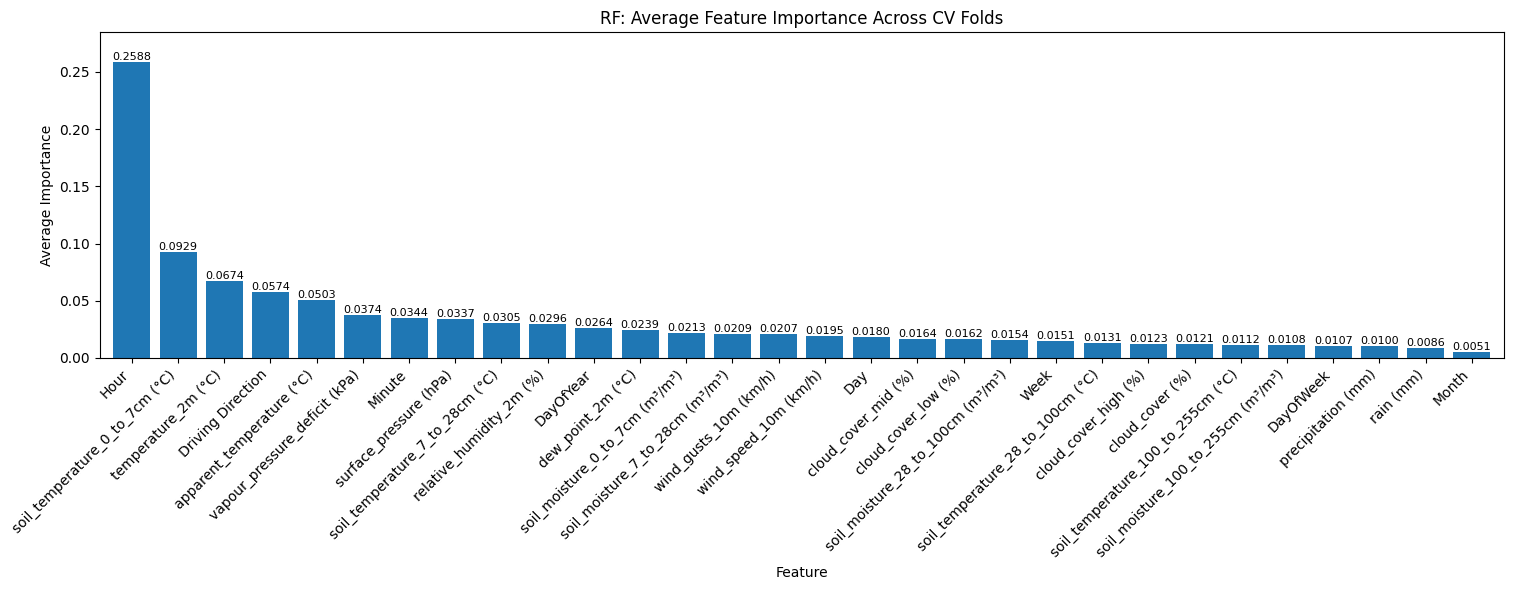

In [ ]:
# @title Feature Importance using Built-in RF Importance

rf_importance_df = pd.concat(rf_all_importances, axis=1)
rf_avg_importance = rf_importance_df.mean(axis=1)

# Combine into one DataFrame
rf_avg_importance_df = pd.DataFrame({
    'Feature': rf_avg_importance.index,
    'Importance': rf_avg_importance.values
})

# Sort for plotting (descending works better for vertical bars)
plot_df = rf_avg_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(max(10, len(plot_df) * 0.5), 6))

bars = plt.bar(plot_df['Feature'], plot_df['Importance'])

plt.xlabel("Feature")
plt.ylabel("Average Importance")
plt.title("RF: Average Feature Importance Across CV Folds")

# Rotate x labels if many features
plt.xticks(rotation=45, ha='right')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.4f}',   # format as needed
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.margins(x=0.01, y=0.1)
plt.show()

# *LSTM*

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Reproducibility
tf.keras.utils.set_random_seed(0)
tf.config.experimental.enable_op_determinism()

# Sequence builder
def create_sequences(data, targets, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(targets[i + window_size])
    return np.array(X), np.array(y)

# Improved model
from tensorflow.keras.regularizers import l2

def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(units=64, return_sequences=True, kernel_regularizer=l2(1e-5)),
        Dropout(0.2),
        LSTM(units=32, return_sequences=False, kernel_regularizer=l2(1e-5)),
        Dropout(0.2),
        Dense(units=32, activation='relu'),
        Dropout(0.1),
        Dense(units=3, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Training loop
lstm_all_metrics = []
WINDOW = 72

for fold, (train_idx, val_idx) in enumerate(tscv.split(X, y)):
    print(f"\n--- Fold {fold+1} ---")

    # 1. Prepare data for the current fold
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_val_fold,   y_val_fold   = X.iloc[val_idx],   y.iloc[val_idx]

    # 2. Scale features (fit only on train)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_val_scaled   = scaler.transform(X_val_fold)

    # 3. Create training sequences
    X_train_seq, y_train_seq = create_sequences(
        X_train_scaled,
        y_train_fold.values,
        WINDOW
    )

    # 4. Create validation sequences with temporal continuity fix
    #    Prepend the last WINDOW steps of training so the first
    #    validation sequence has a proper lead-in
    combined_X = np.concatenate([
        X_train_scaled[-WINDOW:],
        X_val_scaled
    ])
    combined_y = np.concatenate([
        y_train_fold.values[-WINDOW:],
        y_val_fold.values
    ])

    X_val_seq, y_val_seq = create_sequences(combined_X, combined_y, WINDOW)

    # Safety check — create_sequences already produces exactly len(val) sequences
    assert len(X_val_seq) == len(y_val_fold), \
        f"Fold {fold+1}: sequence count {len(X_val_seq)} != val size {len(y_val_fold)}"
    assert np.array_equal(y_val_seq, y_val_fold.values), \
        f"Fold {fold+1}: label misalignment detected!"

    # 5. Skip fold if sequences are empty
    if len(X_train_seq) == 0 or len(X_val_seq) == 0:
        print(f"Skipping fold {fold+1} due to insufficient data.")
        continue

    # 6. Compute class weights from training sequences
    classes = np.unique(y_train_seq)
    weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=y_train_seq
    )
    class_weights = dict(zip(classes, weights))

    # 7. Build improved LSTM model
    lstm_model = build_lstm_model(
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        min_delta=0.001,
        restore_best_weights=True
    )

    # 8. Train
    history = lstm_model.fit(
        X_train_seq,
        y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=100,
        batch_size=64,
        class_weight=class_weights,
        callbacks=[early_stop],
        shuffle=False,         # preserve sequence order
        verbose=0
    )

    # 9. Predict and evaluate
    y_pred_prob = lstm_model.predict(X_val_seq, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)

    metrics = evaluate_metrics(y_val_seq, y_pred)
    lstm_all_metrics.append(metrics)
    print(f"Fold {fold+1} Metrics: {metrics}")

# Average metrics across all folds
avg_results = average_metrics(lstm_all_metrics)

print("\nAverage Metrics Across All Folds:")
for k, v in avg_results.items():
    print(f"{k}: {v:.4f}")

# Stored under its own name (not just `avg_results`, which the XGBoost/RF cells
# above also reuse) so Step 6c can reliably pull the full-feature LSTM F1 later,
# regardless of cell execution order.
lstm_full_feature_f1 = avg_results['F1 Score']



--- Fold 1 ---
Fold 1 Metrics: {'Accuracy': 0.6089543294953559, 'Precision': 0.6208152463603062, 'Recall': 0.6089543294953559, 'F1 Score': 0.61328531712089}

--- Fold 2 ---
Fold 2 Metrics: {'Accuracy': 0.6098959893849248, 'Precision': 0.6109583271694553, 'Recall': 0.6098959893849248, 'F1 Score': 0.6065030120872477}

--- Fold 3 ---
Fold 3 Metrics: {'Accuracy': 0.6925480460557292, 'Precision': 0.7020771060166783, 'Recall': 0.6925480460557292, 'F1 Score': 0.6951597775868567}

Average Metrics Across All Folds:
Accuracy: 0.6371
Precision: 0.6446
Recall: 0.6371
F1 Score: 0.6383


In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

def lstm_permutation_importance(model, X_val_seq, y_val_seq, feature_names):

    # Baseline performance
    baseline_pred = np.argmax(model.predict(X_val_seq, verbose=0), axis=1)
    baseline_acc = accuracy_score(y_val_seq, baseline_pred)

    importances = []

    # Loop through each feature
    for feature_idx in range(X_val_seq.shape[2]):

        # Copy validation data
        X_permuted = X_val_seq.copy()

        # Shuffle ONLY one feature across all samples
        shuffled_feature = X_permuted[:, :, feature_idx].copy()

        # Flatten -> shuffle -> reshape
        flat = shuffled_feature.flatten()
        np.random.shuffle(flat)

        X_permuted[:, :, feature_idx] = flat.reshape(
            shuffled_feature.shape
        )

        # Predict with permuted feature
        permuted_pred = np.argmax(
            model.predict(X_permuted, verbose=0),
            axis=1
        )

        permuted_acc = accuracy_score(y_val_seq, permuted_pred)

        # Importance = drop in accuracy
        importance = baseline_acc - permuted_acc

        importances.append(importance)

    # Create dataframe
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    # Sort descending
    importance_df = importance_df.sort_values(
        by='Importance',
        ascending=False
    ).reset_index(drop=True)

    return importance_df

In [ ]:
# Call the function
importance_df = lstm_permutation_importance(lstm_model, X_val_seq, y_val_seq, X.columns)

# LSTM Feature Importance
print(importance_df)

                               Feature  Importance
0                                 Hour    0.181526
1                    Driving Direction    0.114497
2       soil_temperature_0_to_7cm (°C)    0.011899
3               surface_pressure (hPa)    0.008347
4                  temperature_2m (°C)    0.007405
5            apparent_temperature (°C)    0.007105
6             relative_humidity_2m (%)    0.004451
7        vapour_pressure_deficit (kPa)    0.004109
8                wind_gusts_10m (km/h)    0.003767
9      soil_temperature_7_to_28cm (°C)    0.003467
10                           DayOfWeek    0.001883
11                              Minute    0.001841
12                   dew_point_2m (°C)    0.000642
13                  precipitation (mm)    0.000556
14                                Week    0.000556
15     soil_moisture_7_to_28cm (m³/m³)    0.000257
16               wind_speed_10m (km/h)    0.000171
17                cloud_cover_high (%)    0.000000
18  soil_temperature_100_to_255

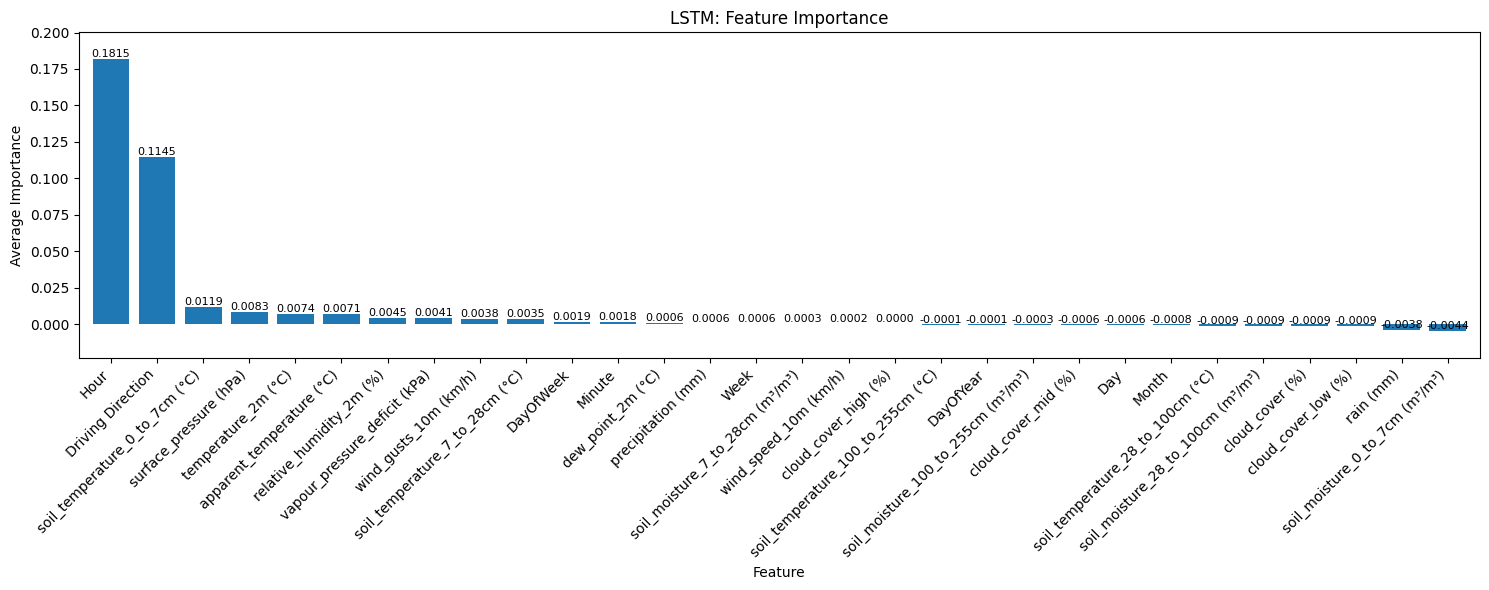

In [ ]:
# @title Feature Importance using Permutation Importance LSTM


# Sort for plotting (descending works better for vertical bars)
plot_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(max(10, len(plot_df) * 0.5), 6))

bars = plt.bar(plot_df['Feature'], plot_df['Importance'])

plt.xlabel("Feature")
plt.ylabel("Average Importance")
plt.title("LSTM: Feature Importance")

# Rotate x labels if many features
plt.xticks(rotation=45, ha='right')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.4f}',   # format as needed
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.margins(x=0.01, y=0.1)
plt.show()

#Negative feature importance imply feature's negative impact on model performance

# **MULTI-MODEL FEATURE SELECTION**


Combines feature rankings from XGBoost, Random Forest, and LSTM into a single consensus ranking. All three models score features on different, non-comparable scales (impurity-based for the trees, permutation-based for the LSTM), so the consensus is built on **ranks**, not raw importance values — this is what makes the three models comparable in the first place.


In [ ]:
# @title Step 1 — Collect averaged importance scores from all 3 models

# XGBoost — mean feature_importances_ across CV folds
xgb_importance_df = pd.concat(xgb_all_importances, axis=1)
xgb_fs = xgb_importance_df.mean(axis=1)

# Random Forest — mean feature_importances_ across CV folds
rf_importance_df = pd.concat(rf_all_importances, axis=1)
rf_fs = rf_importance_df.mean(axis=1)

# LSTM -
lstm_fs = importance_df.set_index('Feature')['Importance']

print("Raw importance summary (mean across folds):\n")
print(pd.DataFrame({"XGBoost": xgb_fs, "RandomForest": rf_fs, "LSTM": lstm_fs}).round(4))

Raw importance summary (mean across folds):

                                    XGBoost  RandomForest    LSTM
Day                                  0.0178        0.0180 -0.0006
DayOfWeek                            0.0154        0.0107  0.0019
DayOfYear                            0.0386        0.0264 -0.0001
Driving Direction                    0.0400        0.0574  0.1145
Hour                                 0.2096        0.2588  0.1815
Minute                               0.0170        0.0344  0.0018
Month                                0.0404        0.0051 -0.0008
Week                                 0.0312        0.0151  0.0006
apparent_temperature (°C)            0.0330        0.0503  0.0071
cloud_cover (%)                      0.0080        0.0121 -0.0009
cloud_cover_high (%)                 0.0091        0.0123  0.0000
cloud_cover_low (%)                  0.0077        0.0162 -0.0009
cloud_cover_mid (%)                  0.0125        0.0164 -0.0006
dew_point_2m (°C)              

### Step 2 — Rank each model's features (Borda-style consensus)

Each model converts its raw importance scores into **ranks** (1 = most important → N = least important), not rescaled values. Ranks are immune to scale and distributional differences between an impurity-based score and a permutation-accuracy-drop score, which is what raw min-max normalization was not robust to.


In [ ]:
# @title Step 2 — Convert each model's importances to ranks (1 = most important)

def to_rank(series):
    """1 = most important feature, N = least important."""
    return series.rank(ascending=False, method="average")

xgb_rank  = to_rank(xgb_fs).rename("XGBoost_Rank")
rf_rank   = to_rank(rf_fs).rename("RandomForest_Rank")
lstm_rank = to_rank(lstm_fs).rename("LSTM_Rank")

n_features = len(X.columns)

# Borda score: higher is better. Converts rank back into an intuitive "points" scale
# where the best-ranked feature in a model gets n_features points, worst gets 1.
xgb_borda  = (n_features + 1 - xgb_rank).rename("XGBoost_Borda")
rf_borda   = (n_features + 1 - rf_rank).rename("RandomForest_Borda")
lstm_borda = (n_features + 1 - lstm_rank).rename("LSTM_Borda")

rank_df = pd.concat([xgb_rank, rf_rank, lstm_rank], axis=1)
print(rank_df.round(1))


                                    XGBoost_Rank  RandomForest_Rank  LSTM_Rank
Driving Direction                            5.0                4.0        2.0
temperature_2m (°C)                          3.0                3.0        5.0
relative_humidity_2m (%)                    25.0               10.0        7.0
dew_point_2m (°C)                           27.0               12.0       13.0
apparent_temperature (°C)                    8.0                5.0        6.0
precipitation (mm)                          24.0               28.0       14.5
rain (mm)                                   23.0               29.0       29.0
soil_temperature_0_to_7cm (°C)               2.0                2.0        3.0
soil_temperature_7_to_28cm (°C)              7.0                9.0       10.0
soil_temperature_28_to_100cm (°C)           13.0               22.0       25.0
soil_temperature_100_to_255cm (°C)          11.0               25.0       19.5
soil_moisture_0_to_7cm (m³/m³)              15.0    

### Step 3 — Build consensus ranking + agreement diagnostics

`Consensus_Rank` is the feature's rank by **average Borda score** — the core ranking you asked for. `Vote_Count` still reports how many models place a feature in their own top half, but it's now a secondary diagnostic rather than the deciding factor. `Rank_Spread` shows *how much the models disagree* about a feature — a feature can get 3 votes while still having wildly different ranks across models, which the old version couldn't distinguish.

Rather than imposing arbitrary tercile cut points on Consensus_Rank, we let k-means find the natural breakpoints in the Mean_Borda score distribution itself. This means the High / Moderate / Low boundaries reflect real gaps
in the data (e.g. a cluster of features that all score similarly high),
not a rule that always puts exactly 1/3 of features in each bucket.

`Importance_Category` labels each feature as **High**, **Moderate**, or **Low** importance. Rather than cutting the ranked list into arbitrary thirds on Consensus_Rank, these tiers come from **k-means clustering (k=3) applied to the consensus Mean Borda scores** — the boundaries fall wherever the data itself shows a natural break in the score distribution. We let k-means find the natural breakpoints in the Mean_Borda score distribution itself. This means the High / Moderate / Low boundaries reflect real gaps in the data (e.g. a cluster of features that all score similarly high), not a rule that always puts exactly 1/3 of features in each bucket.


In [ ]:
# @title Step 3 — Build consensus DataFrame from Borda scores

consensus_df = pd.DataFrame([xgb_borda, rf_borda, lstm_borda]).T
consensus_df.columns = ["XGBoost", "RandomForest", "LSTM"]
consensus_df.index.name = "Feature"

# Mean Borda score across models = the consensus ranking signal
consensus_df["Mean_Borda"] = consensus_df[["XGBoost", "RandomForest", "LSTM"]].mean(axis=1)

# Vote count: how many models place this feature in their own top half (by rank)
top_half = n_features // 2
consensus_df["Vote_Count"] = (
    (xgb_rank  <= top_half).astype(int) +
    (rf_rank   <= top_half).astype(int) +
    (lstm_rank <= top_half).astype(int)
)

# Rank spread: max-min rank across the 3 models for this feature — low spread means
# the models agree closely on WHERE this feature sits, not just THAT it's in the top half
rank_matrix = pd.DataFrame([xgb_rank, rf_rank, lstm_rank]).T
consensus_df["Rank_Spread"] = (rank_matrix.max(axis=1) - rank_matrix.min(axis=1))

consensus_df["Consensus_Rank"] = consensus_df["Mean_Borda"].rank(ascending=False, method="min").astype(int)

consensus_df = consensus_df.sort_values("Mean_Borda", ascending=False)

# --- Importance Category via k-means clustering (data-driven, k=3) ----------
kmeans_borda = KMeans(n_clusters=3, n_init=10, random_state=42)
borda_values = consensus_df[["Mean_Borda"]].values
cluster_labels = kmeans_borda.fit_predict(borda_values)

# KMeans cluster indices (0, 1, 2) are arbitrary — map them to High/Moderate/Low
# by ranking the cluster CENTROIDS, so the cluster with the highest mean Borda
# score is always "High", regardless of which index KMeans happened to assign.
centroid_order = np.argsort(kmeans_borda.cluster_centers_.flatten())[::-1]  # high -> low
cluster_to_label = {
    centroid_order[0]: "High",
    centroid_order[1]: "Moderate",
    centroid_order[2]: "Low",
}
consensus_df["Importance_Category"] = [cluster_to_label[c] for c in cluster_labels]

# Enforce ordering as a categorical so it prints/sorts High -> Moderate -> Low
consensus_df["Importance_Category"] = pd.Categorical(
    consensus_df["Importance_Category"], categories=["High", "Moderate", "Low"], ordered=True
)

cat_counts = consensus_df["Importance_Category"].value_counts().reindex(["High", "Moderate", "Low"])
cat_ranges = consensus_df.groupby("Importance_Category", observed=True)["Mean_Borda"].agg(["min", "max"]).reindex(["High", "Moderate", "Low"])

print("K-means importance tiers (k=3, fit on Mean_Borda scores):")
for tier in ["High", "Moderate", "Low"]:
    n_tier = cat_counts.loc[tier]
    lo, hi = cat_ranges.loc[tier, "min"], cat_ranges.loc[tier, "max"]
    print(f"  {tier:<8}: {n_tier} features  |  Mean_Borda range [{lo:.2f}, {hi:.2f}]")
print()

print("=" * 78)
print("  CONSENSUS FEATURE RANKING  (higher Mean_Borda = more important)")
print("=" * 78)
print(consensus_df.round(2).to_string())

# --- Pairwise agreement between models (Spearman rank correlation) ----------
from scipy.stats import spearmanr

pairs = [("XGBoost vs RandomForest", xgb_rank, rf_rank),
         ("XGBoost vs LSTM",         xgb_rank, lstm_rank),
         ("RandomForest vs LSTM",    rf_rank,  lstm_rank)]

print("\nPairwise rank agreement (Spearman correlation, -1 to 1, 1 = perfect agreement):")
for label, r1, r2 in pairs:
    corr, _ = spearmanr(r1, r2)
    print(f"  {label:<28}: {corr:.3f}")

K-means importance tiers (k=3, fit on Mean_Borda scores):
  High    : 5 features  |  Mean_Borda range [24.67, 30.00]
  Moderate: 9 features  |  Mean_Borda range [16.00, 22.33]
  Low     : 16 features  |  Mean_Borda range [4.00, 13.67]

  CONSENSUS FEATURE RANKING  (higher Mean_Borda = more important)
                                    XGBoost  RandomForest  LSTM  Mean_Borda  Vote_Count  Rank_Spread  Consensus_Rank Importance_Category
Feature                                                                                                                                 
Hour                                   30.0          30.0  30.0       30.00           3          0.0               1                High
soil_temperature_0_to_7cm (°C)         29.0          29.0  28.0       28.67           3          1.0               2                High
temperature_2m (°C)                    28.0          28.0  26.0       27.33           3          2.0               3                High
Driving Direc

In [ ]:
import plotly.graph_objects as go

# @title Step 4 — Visualize consensus ranking

# Consensus bar chart, colored by vote count, error bars show rank spread
color_map_plotly = {3: "#1565C0", 2: "#2E7D32", 1: "#9E9E9E", 0: "#BDBDBD"}
colors_plotly = [color_map_plotly.get(int(v), "#BDBDBD") for v in consensus_df["Vote_Count"]]

fig = go.Figure(data=[
    go.Bar(
        x=consensus_df.index,
        y=consensus_df["Mean_Borda"],
        marker_color=colors_plotly,
        hoverinfo='x+y',
        name='Mean Borda Score'
    )
])

fig.update_layout(
    title_text="Consensus Feature Importance<br>(Mean Borda Score, colored by vote count)",
    xaxis_title="Feature",
    yaxis_title="Mean Borda Score (higher = more important)",
    xaxis=dict(
        tickmode='array',
        tickvals=consensus_df.index.tolist(),
        tickangle=-90
    ),
    hovermode="x unified",
    showlegend=True,
    legend_title_text='Model Agreement',
    legend=dict(
        orientation="v",
        yanchor="top",
        y=0.99,
        xanchor="right",
        x=0.99
    )
)


fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers', marker=dict(size=10, color="#1565C0"),
    legendgroup='model-agreement', showlegend=True, name="All 3 models agree (top half)"
))
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers', marker=dict(size=10, color="#2E7D32"),
    legendgroup='model-agreement', showlegend=True, name="2 of 3 models agree"
))
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers', marker=dict(size=10, color="#9E9E9E"),
    legendgroup='model-agreement', showlegend=True, name="1 model only"
))
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers', marker=dict(size=10, color="#BDBDBD"),
    legendgroup='model-agreement', showlegend=True, name="No model"
))

fig.show()


### Step 5 — Elbow plot: how many features to keep, statistically

Uses the cumulative share of total Borda score captured by the top-K features to locate the elbow — the point past which adding more features contributes little additional consensus importance. This gives a **starting candidate K**, which Step 6 then validates empirically.


In [ ]:
import plotly.graph_objects as go

sorted_borda = consensus_df["Mean_Borda"].sort_values(ascending=False)
cumsum_pct = sorted_borda.cumsum() / sorted_borda.sum()

# Kneedle-style elbow: point of maximum distance from the straight line
# connecting the first and last point of the cumulative curve.
x_vals = np.arange(1, len(cumsum_pct) + 1)
y_vals = cumsum_pct.values
line_vec = np.array([x_vals[-1] - x_vals[0], y_vals[-1] - y_vals[0]], dtype=float)
line_vec = line_vec / np.linalg.norm(line_vec)

distances = []
for x, y_ in zip(x_vals, y_vals):
    point_vec = np.array([x - x_vals[0], y_ - y_vals[0]])
    proj_len = np.dot(point_vec, line_vec)
    proj_point = proj_len * line_vec
    distances.append(np.linalg.norm(point_vec - proj_point))

elbow_k = int(x_vals[np.argmax(distances)])
print(f"Statistical elbow suggests K = {elbow_k} features "
      f"(captures {cumsum_pct.iloc[elbow_k-1]*100:.1f}% of cumulative consensus importance)")

fig = go.Figure()

# Cumulative importance line
fig.add_trace(go.Scatter(
    x=x_vals,
    y=y_vals,
    mode='lines+markers',
    name='Cumulative consensus importance',
    marker=dict(size=4),
    line=dict(color='#1565C0')
))

# Elbow point vertical line
fig.add_vline(
    x=elbow_k,
    line_dash='dash',
    line_color='#C62828',
    annotation_text=f"Elbow at K={elbow_k}",
    annotation_position="top right",
    name=f"Elbow at K={elbow_k}"
)

# 80% reference horizontal line
fig.add_hline(
    y=0.8,
    line_dash='dot',
    line_color='gray',
    line_width=1,
    annotation_text="80% reference line",
    annotation_position="bottom right",
    name="80% reference line"
)

fig.update_layout(
    title_text="Elbow Plot — Candidate K for Feature Count",
    xaxis_title="Number of top-ranked features (by consensus)",
    yaxis_title="Cumulative share of total Borda score",
    xaxis=dict(
        tickmode='array',
        tickvals=x_vals,
        ticktext=consensus_df.index.tolist(),
        tickangle=-90
    ),
    hovermode="x unified"
)

fig.show()


Statistical elbow suggests K = 14 features (captures 66.2% of cumulative consensus importance)


### Step 6 — Validate K empirically: sweep feature counts and compare CV F1

The elbow value from Step 5 is a **starting guess**, not the final answer. Step 6a/6b re-run cross-validated F1 for a range of K values around the elbow (using consensus-ranked top-K features) on **XGBoost and Random Forest** — these are cheap enough to sweep across every candidate K — and pick the smallest K whose performance is within a small tolerance of the full-feature baseline.

LSTM is checked too, because Step 3's diagnostics showed it doesn't always agree with the two tree models — some selected features were voted in by XGBoost/RandomForest while LSTM ranked them low. But LSTM is far more expensive to retrain, so instead of sweeping it across every K, **Step 6c trains it once**, only on the final `FINAL_K` chosen by 6a/6b, and compares that against the full-feature LSTM score already computed earlier. Same "does it hold up" check as the tree models get, without paying for a full grid.


In [ ]:
# @title Step 6a — Sweep K and compare CV F1 (XGBoost + Random Forest)
# LSTM is intentionally left out of this grid — see Step 6c below for why,
# and how it still gets validated without the extra training cost.

consensus_order = consensus_df.sort_values("Mean_Borda", ascending=False).index.tolist()

# Candidate K values: a spread around the statistical elbow, plus the full set
candidate_ks = sorted(set(
    [max(3, elbow_k - 4), max(3, elbow_k - 2), elbow_k,
     elbow_k + 2, elbow_k + 4, len(consensus_order)]
))
candidate_ks = [k for k in candidate_ks if k <= len(consensus_order)]

results = []

for k in candidate_ks:
    feats_k = consensus_order[:k]

    xgb_scores, rf_scores = [], []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(train_val)):
        X_train_k, X_val_k = X.loc[train_idx, feats_k], X.loc[val_idx, feats_k]
        y_train_k, y_val_k = y.loc[train_idx], y.loc[val_idx]

        xgb_k = XGBClassifier(
            objective="multi:softmax", num_class=3, eval_metric="mlogloss",
            n_estimators=100, max_depth=4, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1,
        )
        xgb_k.fit(X_train_k, y_train_k)
        xgb_scores.append(f1_score(y_val_k, xgb_k.predict(X_val_k), average="weighted", zero_division=0))

        rf_k = RandomForestClassifier(
            n_estimators=100, max_features="sqrt",
            min_samples_split=10, min_samples_leaf=5,
            class_weight="balanced", random_state=42, n_jobs=-1,
        )
        rf_k.fit(X_train_k, y_train_k)
        rf_scores.append(f1_score(y_val_k, rf_k.predict(X_val_k), average="weighted", zero_division=0))

    results.append({
        "K": k,
        "XGB_F1": np.mean(xgb_scores),
        "RF_F1":  np.mean(rf_scores),
    })
    print(f"K={k:>2}  |  XGB F1={np.mean(xgb_scores):.4f}  |  RF F1={np.mean(rf_scores):.4f}")

sweep_df = pd.DataFrame(results).set_index("K")


K=10  |  XGB F1=0.6671  |  RF F1=0.6539
K=12  |  XGB F1=0.6665  |  RF F1=0.6542
K=14  |  XGB F1=0.6675  |  RF F1=0.6537
K=16  |  XGB F1=0.6544  |  RF F1=0.6522
K=18  |  XGB F1=0.6643  |  RF F1=0.6549
K=30  |  XGB F1=0.6650  |  RF F1=0.6517


In [ ]:
import plotly.graph_objects as go

full_xgb_f1 = sweep_df["XGB_F1"].iloc[-1]
full_rf_f1  = sweep_df["RF_F1"].iloc[-1]
TOLERANCE = 0.02  # F1 points we're willing to trade away for fewer features

fig = go.Figure()

# XGBoost F1 line
fig.add_trace(go.Scatter(
    x=sweep_df.index,
    y=sweep_df["XGB_F1"],
    mode='lines+markers',
    name='XGBoost F1',
    marker=dict(symbol='circle')
))

# Random Forest F1 line
fig.add_trace(go.Scatter(
    x=sweep_df.index,
    y=sweep_df["RF_F1"],
    mode='lines+markers',
    name='Random Forest F1',
    marker=dict(symbol='square')
))

# Full-feature XGB F1 - TOLERANCE horizontal line
fig.add_hline(
    y=full_xgb_f1 - TOLERANCE,
    line_dash='dot',
    line_color='gray',
    line_width=1,
    annotation_text=f"Full-feature XGB F1 - {TOLERANCE}",
    annotation_position="top right",
    name=f"Full-feature XGB F1 - {TOLERANCE}"
)

# Statistical elbow vertical line
fig.add_vline(
    x=elbow_k,
    line_dash='dash',
    line_color='#C62828',
    line_width=1,
    annotation_text=f"Statistical elbow (K={elbow_k})",
    annotation_position="top left",
    name=f"Statistical elbow (K={elbow_k})"
)

fig.update_layout(
    title_text="Performance vs Feature Count (XGBoost + Random Forest)",
    xaxis_title="Number of top consensus-ranked features (K)",
    yaxis_title="Weighted F1 (CV mean)",
    hovermode="x unified"
)

fig.show()

# Pick the smallest K whose average (XGB, RF) F1 is within TOLERANCE of the full-feature score
full_avg_f1 = (full_xgb_f1 + full_rf_f1) / 2
sweep_df["Avg_F1"] = sweep_df[["XGB_F1", "RF_F1"]].mean(axis=1)
valid_ks = sweep_df[sweep_df["Avg_F1"] >= full_avg_f1 - TOLERANCE].index

FINAL_K = int(min(valid_ks)) if len(valid_ks) > 0 else int(sweep_df["Avg_F1"].idxmax())

print(f"\nStatistical elbow guess : K = {elbow_k}")
print(f"Performance-validated K : K = {FINAL_K}  "
      f"(avg F1 = {sweep_df.loc[FINAL_K, 'Avg_F1']:.4f} vs full-feature avg F1 = {full_avg_f1:.4f})")

selected_features = consensus_order[:FINAL_K]
print(f"\nFinal selected features ({FINAL_K}):")
for rank, f in enumerate(selected_features, 1):
    row = consensus_df.loc[f]
    print(f"  {rank:>2}. {f:<35} Mean_Borda={row['Mean_Borda']:.2f}  votes={int(row['Vote_Count'])}  rank_spread={row['Rank_Spread']:.1f}")


Statistical elbow guess : K = 14
Performance-validated K : K = 10  (avg F1 = 0.6605 vs full-feature avg F1 = 0.6583)

Final selected features (10):
   1. Hour                                Mean_Borda=30.00  votes=3  rank_spread=0.0
   2. soil_temperature_0_to_7cm (°C)      Mean_Borda=28.67  votes=3  rank_spread=1.0
   3. temperature_2m (°C)                 Mean_Borda=27.33  votes=3  rank_spread=2.0
   4. Driving Direction                   Mean_Borda=27.33  votes=3  rank_spread=3.0
   5. apparent_temperature (°C)           Mean_Borda=24.67  votes=3  rank_spread=3.0
   6. soil_temperature_7_to_28cm (°C)     Mean_Borda=22.33  votes=3  rank_spread=3.0
   7. surface_pressure (hPa)              Mean_Borda=21.67  votes=2  rank_spread=12.0
   8. vapour_pressure_deficit (kPa)       Mean_Borda=21.67  votes=3  rank_spread=8.0
   9. DayOfYear                           Mean_Borda=18.83  votes=2  rank_spread=13.5
  10. Minute                              Mean_Borda=18.67  votes=2  rank_spread=11.

### Step 6c — Validate K empirically: Confirm LSTM holds up at FINAL_K (single run, not a full grid)

Why not sweep LSTM across every K like XGBoost/RF above: LSTM training is the
expensive, and LSTM's permutation importance already fed into the consensus ranking that produced FINAL_K (Step 1), so a full grid mostly re-confirms what the elbow + tree sweep already agree on. Instead we:
   1. Reuse the full-feature LSTM CV score already computed earlier
      (lstm_full_feature_f1, from the LSTM training cell) — no retraining.
   2. Train LSTM exactly ONCE, on the FINAL_K feature set chosen in Step 6b Same "before vs after" check XGBoost/RF get in Step 6a, at a fraction of the training cost of a full multi-K, multi-fold LSTM grid.


In [ ]:
# @title Step 6c — Confirm LSTM holds up at FINAL_K (single run, not a full grid)

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping


def train_eval_lstm_k(feats_k):
    """
    Re-runs the same TimeSeriesSplit CV used to train the full LSTM (Step 'LSTM and
    Evaluation using Cross Validation' cell), restricted to `feats_k` columns.
    Returns the mean weighted F1 across folds.
    """
    X_k = X[feats_k]
    fold_f1 = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_k, y)):
        X_train_fold, y_train_fold = X_k.iloc[train_idx], y.iloc[train_idx]
        X_val_fold,   y_val_fold   = X_k.iloc[val_idx],   y.iloc[val_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled   = scaler.transform(X_val_fold)

        X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_fold.values, WINDOW)

        # Same temporal-continuity fix as the original LSTM CV loop:
        # prepend the last WINDOW training steps so the first val sequence has lead-in
        combined_X = np.concatenate([X_train_scaled[-WINDOW:], X_val_scaled])
        combined_y = np.concatenate([y_train_fold.values[-WINDOW:], y_val_fold.values])
        X_val_seq, y_val_seq = create_sequences(combined_X, combined_y, WINDOW)

        if len(X_train_seq) == 0 or len(X_val_seq) == 0:
            continue

        classes = np.unique(y_train_seq)
        weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_seq)
        class_weights = dict(zip(classes, weights))

        model_k = build_lstm_model(input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]))
        early_stop = EarlyStopping(monitor="val_loss", patience=10, min_delta=0.001, restore_best_weights=True)

        model_k.fit(
            X_train_seq, y_train_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=100, batch_size=64,
            class_weight=class_weights,
            callbacks=[early_stop],
            shuffle=False, verbose=0
        )

        y_pred = np.argmax(model_k.predict(X_val_seq, verbose=0), axis=1)
        fold_f1.append(f1_score(y_val_seq, y_pred, average="weighted", zero_division=0))

    return np.mean(fold_f1) if fold_f1 else np.nan


full_lstm_f1    = lstm_full_feature_f1                  # reused, not retrained
lstm_f1_final_k = train_eval_lstm_k(selected_features)  # the one and only extra LSTM fit

sweep_df.loc[FINAL_K, "LSTM_F1"] = lstm_f1_final_k  # so Step 7 can read it like XGB/RF

print(f"LSTM F1 — full features ({X.shape[1]})   : {full_lstm_f1:.4f}")
print(f"LSTM F1 — selected features ({FINAL_K})  : {lstm_f1_final_k:.4f}")
diff = lstm_f1_final_k - full_lstm_f1
print(f"Change                                   : {diff:+.4f}")
if diff >= -TOLERANCE:
    print("LSTM performance holds within tolerance at FINAL_K.")
else:
    print("LSTM performance drop exceeds tolerance at FINAL_K — consider raising FINAL_K, "
          "or note that LSTM may need a different feature set than the tree models.")


LSTM F1 — full features (30)   : 0.6383
LSTM F1 — selected features (10)  : 0.6494
Change                                   : +0.0110
LSTM performance holds within tolerance at FINAL_K.


In [ ]:
import plotly.graph_objects as go

X_selected      = X[selected_features]
X_test_selected = X_test[selected_features]

print("=" * 60)
print("  FINAL FEATURE SELECTION SUMMARY")
print("=" * 60)
print(f"  Original feature count : {X.shape[1]}")
print(f"  Selected feature count : {len(selected_features)}")
print(f"  XGBoost F1  (full vs selected)      : {full_xgb_f1:.4f}  ->  {sweep_df.loc[FINAL_K, 'XGB_F1']:.4f}")
print(f"  RandomForest F1 (full vs selected)  : {full_rf_f1:.4f}  ->  {sweep_df.loc[FINAL_K, 'RF_F1']:.4f}")
print(f"  LSTM F1 (full vs selected, single confirmatory run) : {full_lstm_f1:.4f}  ->  {sweep_df.loc[FINAL_K, 'LSTM_F1']:.4f}")
diff = sweep_df.loc[FINAL_K, "Avg_F1"] - full_avg_f1
print(f"  Average F1 change (XGBoost + RF, basis for FINAL_K) : {diff:+.4f}")
if diff >= -TOLERANCE:
    print("  Reduction is VALID — performance held within tolerance with fewer features.")
else:
    print("  Performance drop exceeds tolerance — consider raising FINAL_K.")

# Heatmap: rank position of each selected feature, per model (1 = best)
heatmap_ranks = rank_df.loc[selected_features]

fig = go.Figure(data=go.Heatmap(
    z=heatmap_ranks.values.T,
    x=heatmap_ranks.index.tolist(),
    y=heatmap_ranks.columns.tolist(),
    colorscale='YlGnBu_r',
    colorbar=dict(title='Rank (1 = most important)')
))

fig.update_layout(
    title='Selected Features — Rank per Model (lower = more important)',
    xaxis_title='Feature',
    yaxis_title='Model',
    xaxis=dict(tickangle=-45, automargin=True),
    yaxis=dict(automargin=True)
)

# Add annotations (text labels on heatmap cells)
annotations = []
for i, col in enumerate(heatmap_ranks.columns):
    for j, row in enumerate(heatmap_ranks.index):
        annotations.append(go.layout.Annotation(
            x=row,
            y=col,
            text=str(int(heatmap_ranks.iloc[j, i])),
            xref="x1",
            yref="y1",
            showarrow=False,
            font=dict(color="black")
        ))
fig.update_layout(annotations=annotations)

fig.show()

selected_features = consensus_order[:FINAL_K]
print(f"\nFinal selected features ({FINAL_K}):")
for rank, f in enumerate(selected_features, 1):
    row = consensus_df.loc[f]
    print(f"  {rank:>2}. {f:<35} Mean_Borda={row['Mean_Borda']:.2f}  votes={int(row['Vote_Count'])}  rank_spread={row['Rank_Spread']:.1f}")

  FINAL FEATURE SELECTION SUMMARY
  Original feature count : 30
  Selected feature count : 10
  XGBoost F1  (full vs selected)      : 0.6650  ->  0.6671
  RandomForest F1 (full vs selected)  : 0.6517  ->  0.6539
  LSTM F1 (full vs selected, single confirmatory run) : 0.6383  ->  0.6494
  Average F1 change (XGBoost + RF, basis for FINAL_K) : +0.0022
  Reduction is VALID — performance held within tolerance with fewer features.



Final selected features (10):
   1. Hour                                Mean_Borda=30.00  votes=3  rank_spread=0.0
   2. soil_temperature_0_to_7cm (°C)      Mean_Borda=28.67  votes=3  rank_spread=1.0
   3. temperature_2m (°C)                 Mean_Borda=27.33  votes=3  rank_spread=2.0
   4. Driving Direction                   Mean_Borda=27.33  votes=3  rank_spread=3.0
   5. apparent_temperature (°C)           Mean_Borda=24.67  votes=3  rank_spread=3.0
   6. soil_temperature_7_to_28cm (°C)     Mean_Borda=22.33  votes=3  rank_spread=3.0
   7. surface_pressure (hPa)              Mean_Borda=21.67  votes=2  rank_spread=12.0
   8. vapour_pressure_deficit (kPa)       Mean_Borda=21.67  votes=3  rank_spread=8.0
   9. DayOfYear                           Mean_Borda=18.83  votes=2  rank_spread=13.5
  10. Minute                              Mean_Borda=18.67  votes=2  rank_spread=11.0


In [ ]:
# @title Feature Selection using FINAL_K (data-driven, from elbow + F1-sweep)

print("=" * 60)
print(f"  TOP {FINAL_K} FEATURES (out of {n_features}) — FINAL_K SELECTION")
print("=" * 60)
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:>2}. {feat}")

dropped_features = [f for f in X.columns if f not in selected_features]
print(f"\nDropped {len(dropped_features)} features:")
for feat in dropped_features:
    print(f"   - {feat}")

X_selected = X[selected_features]
X_test_selected = X_test[selected_features]

print(f"\nX (original) shape      : {X.shape}")
print(f"X_selected shape        : {X_selected.shape}")
print(f"X_test (original) shape : {X_test.shape}")
print(f"X_test_selected shape   : {X_test_selected.shape}")

  TOP 10 FEATURES (out of 30) — FINAL_K SELECTION
   1. Hour
   2. soil_temperature_0_to_7cm (°C)
   3. temperature_2m (°C)
   4. Driving Direction
   5. apparent_temperature (°C)
   6. soil_temperature_7_to_28cm (°C)
   7. surface_pressure (hPa)
   8. vapour_pressure_deficit (kPa)
   9. DayOfYear
  10. Minute

Dropped 20 features:
   - relative_humidity_2m (%)
   - dew_point_2m (°C)
   - precipitation (mm)
   - rain (mm)
   - soil_temperature_28_to_100cm (°C)
   - soil_temperature_100_to_255cm (°C)
   - soil_moisture_0_to_7cm (m³/m³)
   - soil_moisture_7_to_28cm (m³/m³)
   - soil_moisture_28_to_100cm (m³/m³)
   - soil_moisture_100_to_255cm (m³/m³)
   - cloud_cover (%)
   - cloud_cover_low (%)
   - cloud_cover_mid (%)
   - cloud_cover_high (%)
   - wind_speed_10m (km/h)
   - wind_gusts_10m (km/h)
   - Day
   - DayOfWeek
   - Week
   - Month

X (original) shape      : (93452, 30)
X_selected shape        : (93452, 10)
X_test (original) shape : (4032, 30)
X_test_selected shape   : (4032, 


  XGBoost (Top-10) — Fold 0 — CLASSIFICATION METRICS
  Accuracy  : 0.6522  (65.22%)
  Precision : 0.6636
  Recall    : 0.6522
  F1 Score  : 0.6472

Detailed Report:
              precision    recall  f1-score   support

         Low       0.88      0.67      0.76      7058
      Medium       0.61      0.78      0.69     10960
        High       0.49      0.36      0.42      5345

    accuracy                           0.65     23363
   macro avg       0.66      0.61      0.62     23363
weighted avg       0.66      0.65      0.65     23363


  XGBoost (Top-10) — Fold 1 — CLASSIFICATION METRICS
  Accuracy  : 0.6527  (65.27%)
  Precision : 0.7034
  Recall    : 0.6527
  F1 Score  : 0.6513

Detailed Report:
              precision    recall  f1-score   support

         Low       0.88      0.58      0.70      8441
      Medium       0.55      0.82      0.66      9567
        High       0.69      0.46      0.55      5355

    accuracy                           0.65     23363
   macro avg   

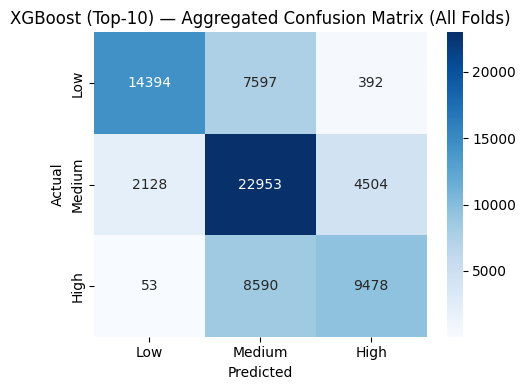

In [ ]:
# @title Re-Evaluate XGBoost — Top-10 Selected Features

xgb_sel_metrics = []
xgb_sel_confusions = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(train_val)):

    xgb_sel_model = XGBClassifier(
            objective        = 'multi:softmax',
            num_class        = 3,
            eval_metric      = 'mlogloss',
            n_estimators     = 100,
            max_depth        = 4,
            learning_rate    = 0.1,
            subsample        = 0.8,
            colsample_bytree = 0.8,
            random_state     = 42,
            n_jobs           = -1,
    )

    X_train_sel = X_selected.loc[train_idx]
    y_train_sel = y.loc[train_idx]

    X_val_sel = X_selected.loc[val_idx]
    y_val_sel = y.loc[val_idx]

    xgb_sel_model.fit(X_train_sel, y_train_sel)
    y_pred_sel = xgb_sel_model.predict(X_val_sel)

    metrics = get_classification_metrics(y_val_sel, y_pred_sel, f"XGBoost (Top-10) — Fold {fold}")
    xgb_sel_metrics.append(metrics)
    xgb_sel_confusions.append(confusion_matrix(y_val_sel, y_pred_sel, labels=[0, 1, 2]))

xgb_sel_avg = average_metrics(xgb_sel_metrics)

print("\n" + "=" * 60)
print("  XGBoost (Top-10 Features) — Average Metrics Across Folds")
print("=" * 60)
for k, v in xgb_sel_avg.items():
    print(f"  {k}: {v:.4f}")

# Aggregated confusion matrix across all folds
xgb_sel_cm = np.sum(xgb_sel_confusions, axis=0)
plt.figure(figsize=(5, 4))
sns.heatmap(xgb_sel_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost (Top-10) — Aggregated Confusion Matrix (All Folds)')
plt.tight_layout()
plt.show()


  Random Forest (Top-10) — Fold 0 — CLASSIFICATION METRICS
  Accuracy  : 0.6052  (60.52%)
  Precision : 0.6419
  Recall    : 0.6052
  F1 Score  : 0.6127

Detailed Report:
              precision    recall  f1-score   support

         Low       0.82      0.69      0.75      7058
      Medium       0.63      0.52      0.57     10960
        High       0.43      0.67      0.52      5345

    accuracy                           0.61     23363
   macro avg       0.63      0.63      0.61     23363
weighted avg       0.64      0.61      0.61     23363


  Random Forest (Top-10) — Fold 1 — CLASSIFICATION METRICS
  Accuracy  : 0.6491  (64.91%)
  Precision : 0.6643
  Recall    : 0.6491
  F1 Score  : 0.6518

Detailed Report:
              precision    recall  f1-score   support

         Low       0.78      0.63      0.70      8441
      Medium       0.57      0.68      0.62      9567
        High       0.64      0.61      0.63      5355

    accuracy                           0.65     23363
   

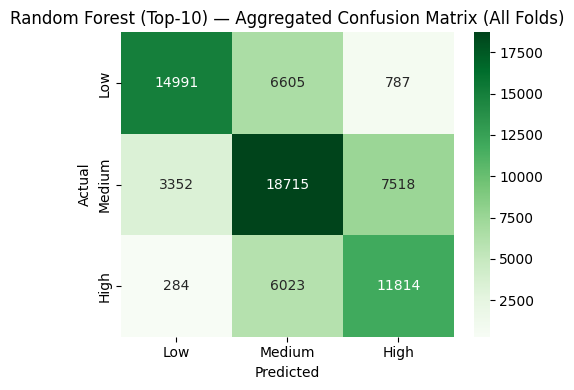

In [ ]:
# @title Re-Evaluate Random Forest — Top-10 Selected Features

rf_sel_metrics = []
rf_sel_confusions = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(train_val)):

    rf_sel_model = RandomForestClassifier(
            n_estimators       = 100,
            max_depth          = None,
            max_features       = 'sqrt',
            min_samples_split  = 10,
            min_samples_leaf   = 5,
            class_weight       = 'balanced',
            random_state       = 42,
            n_jobs             = -1,
    )

    X_train_sel = X_selected.loc[train_idx]
    y_train_sel = y.loc[train_idx]

    X_val_sel = X_selected.loc[val_idx]
    y_val_sel = y.loc[val_idx]

    rf_sel_model.fit(X_train_sel, y_train_sel)
    y_pred_sel = rf_sel_model.predict(X_val_sel)

    metrics = get_classification_metrics(y_val_sel, y_pred_sel, f"Random Forest (Top-10) — Fold {fold}")
    rf_sel_metrics.append(metrics)
    rf_sel_confusions.append(confusion_matrix(y_val_sel, y_pred_sel, labels=[0, 1, 2]))

rf_sel_avg = average_metrics(rf_sel_metrics)

print("\n" + "=" * 60)
print("  Random Forest (Top-10 Features) — Average Metrics Across Folds")
print("=" * 60)
for k, v in rf_sel_avg.items():
    print(f"  {k}: {v:.4f}")

# Aggregated confusion matrix across all folds
rf_sel_cm = np.sum(rf_sel_confusions, axis=0)
plt.figure(figsize=(5, 4))
sns.heatmap(rf_sel_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest (Top-10) — Aggregated Confusion Matrix (All Folds)')
plt.tight_layout()
plt.show()


  LSTM (Top-10) — Fold 1 — CLASSIFICATION METRICS
  Accuracy  : 0.6215  (62.15%)
  Precision : 0.6577
  Recall    : 0.6215
  F1 Score  : 0.6284

Detailed Report:
              precision    recall  f1-score   support

         Low       0.85      0.71      0.77      7058
      Medium       0.64      0.53      0.58     10960
        High       0.45      0.71      0.55      5345

    accuracy                           0.62     23363
   macro avg       0.64      0.65      0.63     23363
weighted avg       0.66      0.62      0.63     23363


  LSTM (Top-10) — Fold 2 — CLASSIFICATION METRICS
  Accuracy  : 0.6351  (63.51%)
  Precision : 0.6615
  Recall    : 0.6351
  F1 Score  : 0.6370

Detailed Report:
              precision    recall  f1-score   support

         Low       0.82      0.58      0.68      8441
      Medium       0.56      0.60      0.58      9567
        High       0.59      0.78      0.67      5355

    accuracy                           0.64     23363
   macro avg       0.

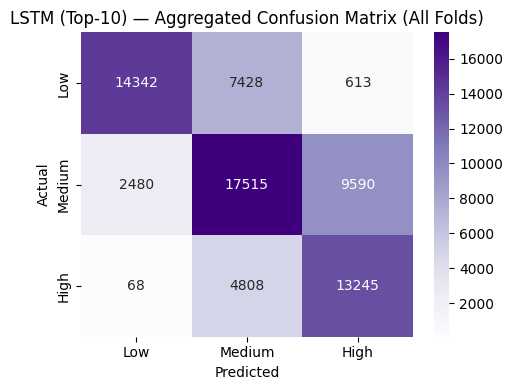

In [ ]:
# @title Re-Evaluate LSTM — Top-10 Selected Features

def evaluate_lstm_full_metrics(feats_k, model_label="LSTM"):
    """Same TimeSeriesSplit + sequence-building protocol as the original LSTM CV cell,
    restricted to `feats_k` columns. Returns per-fold metric dicts (from
    get_classification_metrics) and per-fold confusion matrices."""
    tf.keras.utils.set_random_seed(0)
    tf.config.experimental.enable_op_determinism()

    X_k = X[feats_k]
    fold_metrics = []
    fold_confusions = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_k, y)):
        X_train_fold, y_train_fold = X_k.iloc[train_idx], y.iloc[train_idx]
        X_val_fold,   y_val_fold   = X_k.iloc[val_idx],   y.iloc[val_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled   = scaler.transform(X_val_fold)

        X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_fold.values, WINDOW)

        # Prepend the last WINDOW training steps so the first val sequence has lead-in
        combined_X = np.concatenate([X_train_scaled[-WINDOW:], X_val_scaled])
        combined_y = np.concatenate([y_train_fold.values[-WINDOW:], y_val_fold.values])
        X_val_seq, y_val_seq = create_sequences(combined_X, combined_y, WINDOW)

        if len(X_train_seq) == 0 or len(X_val_seq) == 0:
            print(f"Skipping fold {fold + 1} due to insufficient data.")
            continue

        classes = np.unique(y_train_seq)
        weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_seq)
        class_weights = dict(zip(classes, weights))

        model_k = build_lstm_model(input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]))
        early_stop = EarlyStopping(monitor="val_loss", patience=10, min_delta=0.001, restore_best_weights=True)

        model_k.fit(
            X_train_seq, y_train_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=100, batch_size=64,
            class_weight=class_weights,
            callbacks=[early_stop],
            shuffle=False, verbose=0
        )

        y_pred = np.argmax(model_k.predict(X_val_seq, verbose=0), axis=1)

        metrics = get_classification_metrics(y_val_seq, y_pred, f"{model_label} — Fold {fold + 1}")
        fold_metrics.append(metrics)
        fold_confusions.append(confusion_matrix(y_val_seq, y_pred, labels=[0, 1, 2]))

    return fold_metrics, fold_confusions


lstm_sel_metrics, lstm_sel_confusions = evaluate_lstm_full_metrics(selected_features, model_label="LSTM (Top-10)")

lstm_sel_avg = average_metrics(lstm_sel_metrics)

print("\n" + "=" * 60)
print("  LSTM (Top-10 Features) — Average Metrics Across Folds")
print("=" * 60)
for k, v in lstm_sel_avg.items():
    print(f"  {k}: {v:.4f}")

# Aggregated confusion matrix across all folds
lstm_sel_cm = np.sum(lstm_sel_confusions, axis=0)
plt.figure(figsize=(5, 4))
sns.heatmap(lstm_sel_cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LSTM (Top-10) — Aggregated Confusion Matrix (All Folds)')
plt.tight_layout()

In [ ]:
# @title Full (30) vs Top-10 Selected — Model Comparison Summary

full_xgb_avg  = average_metrics(xgb_all_metrics)
full_rf_avg   = average_metrics(rf_all_metrics)
full_lstm_avg = average_metrics(lstm_all_metrics)

comparison_rows = []
for model_name, full_avg, sel_avg in [
    ("XGBoost",      full_xgb_avg,  xgb_sel_avg),
    ("RandomForest", full_rf_avg,   rf_sel_avg),
    ("LSTM",         full_lstm_avg, lstm_sel_avg),
]:
    for metric in ["Accuracy", "Precision", "Recall", "F1 Score"]:
        comparison_rows.append({
            "Model": model_name,
            "Metric": metric,
            "Full (30 features)": round(full_avg[metric], 4),
            "Selected (10 features)": round(sel_avg[metric], 4),
            "Change": round(sel_avg[metric] - full_avg[metric], 4),
        })

comparison_df = pd.DataFrame(comparison_rows)

print("=" * 78)
print("  MODEL RE-EVALUATION SUMMARY — Full (30) vs Selected (10) Features")
print("=" * 78)
print(comparison_df.to_string(index=False))

# Grouped bar chart: Full vs Selected, per model, per metric
import plotly.graph_objects as go

metrics_order = ["Accuracy", "Precision", "Recall", "F1 Score"]
models_order  = ["XGBoost", "RandomForest", "LSTM"]
x_labels = [f"{m}<br>{metric}" for m in models_order for metric in metrics_order]

fig = go.Figure()
for feat_set, color in [("Full (30 features)", "#9E9E9E"), ("Selected (10 features)", "#1565C0")]:
    y_vals = [
        comparison_df.loc[(comparison_df["Model"] == m) & (comparison_df["Metric"] == metric), feat_set].values[0]
        for m in models_order for metric in metrics_order
    ]
    fig.add_trace(go.Bar(name=feat_set, x=x_labels, y=y_vals, marker_color=color))

fig.update_layout(
    barmode='group',
    title_text="Model Performance — Full Feature Set (30) vs Top-10 Selected Features",
    yaxis_title="Score",
    xaxis_tickangle=-45,
    legend_title_text="Feature Set"
)
fig.show()

  MODEL RE-EVALUATION SUMMARY — Full (30) vs Selected (10) Features
       Model    Metric  Full (30 features)  Selected (10 features)  Change
     XGBoost  Accuracy              0.6609                  0.6681  0.0071
     XGBoost Precision              0.6902                  0.6948  0.0046
     XGBoost    Recall              0.6609                  0.6681  0.0071
     XGBoost  F1 Score              0.6565                  0.6671  0.0106
RandomForest  Accuracy              0.6447                  0.6495  0.0047
RandomForest Precision              0.6701                  0.6721  0.0020
RandomForest    Recall              0.6447                  0.6495  0.0047
RandomForest  F1 Score              0.6493                  0.6540  0.0046
        LSTM  Accuracy              0.6371                  0.6435  0.0063
        LSTM Precision              0.6446                  0.6715  0.0268
        LSTM    Recall              0.6371                  0.6435  0.0063
        LSTM  F1 Score          

##Hyperparameter Tuning — LSTM (Top-10 Features) via KerasTuner




In [ ]:
# @title Manual WINDOW Sweep (Baseline Architecture, Top-10 Features)

CANDIDATE_WINDOWS = [18, 36, 72, 108, 144] #3h, 6h, 12h, 18h, 24h


def evaluate_lstm_baseline_at_window(feats_k, window):
    """Baseline (untuned) LSTM architecture (build_lstm_model), evaluated at a
    given lookback window — used to pick BEST_WINDOW before any hyperparameter
    tuning happens."""
    X_k = X[feats_k]
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_k, y)):
        tf.keras.utils.set_random_seed(0)
        tf.config.experimental.enable_op_determinism()

        X_train_fold, y_train_fold = X_k.iloc[train_idx], y.iloc[train_idx]
        X_val_fold,   y_val_fold   = X_k.iloc[val_idx],   y.iloc[val_idx]

        if len(X_train_fold) <= window or len(X_val_fold) == 0:
            print(f"  Skipping fold {fold + 1} (window={window}) — insufficient rows.")
            continue

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled   = scaler.transform(X_val_fold)

        X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_fold.values, window)

        combined_X = np.concatenate([X_train_scaled[-window:], X_val_scaled])
        combined_y = np.concatenate([y_train_fold.values[-window:], y_val_fold.values])
        X_val_seq, y_val_seq = create_sequences(combined_X, combined_y, window)

        if len(X_train_seq) == 0 or len(X_val_seq) == 0:
            print(f"  Skipping fold {fold + 1} (window={window}) — insufficient sequences.")
            continue

        classes = np.unique(y_train_seq)
        weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_seq)
        class_weights = dict(zip(classes, weights))

        model_k = build_lstm_model(input_shape=(window, X_k.shape[1]))
        early_stop = EarlyStopping(monitor="val_loss", patience=10, min_delta=0.001, restore_best_weights=True)

        model_k.fit(
            X_train_seq, y_train_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=100, batch_size=64,
            class_weight=class_weights,
            callbacks=[early_stop],
            shuffle=False, verbose=0
        )

        y_pred = np.argmax(model_k.predict(X_val_seq, verbose=0), axis=1)
        fold_metrics.append(evaluate_metrics(y_val_seq, y_pred))

    return fold_metrics


# WINDOW = 72 with the baseline architecture was already evaluated in the
# "Re-Evaluate LSTM — Top-10 Selected Features" cell above (lstm_sel_avg) —
# reuse it instead of retraining.
window_sweep_results = [{**lstm_sel_avg, "Window": WINDOW}]

for window in [w for w in CANDIDATE_WINDOWS if w != WINDOW]:
    print(f"\n{'=' * 60}\n  Testing WINDOW = {window}\n{'=' * 60}")
    fold_metrics = evaluate_lstm_baseline_at_window(selected_features, window)

    if not fold_metrics:
        print(f"  WINDOW={window}: no valid folds — skipped (likely too few rows for this window).")
        continue

    avg = average_metrics(fold_metrics)
    avg["Window"] = window
    window_sweep_results.append(avg)
    print(f"WINDOW={window:>3} | Accuracy={avg['Accuracy']:.4f} | F1 Score={avg['F1 Score']:.4f}")

window_sweep_df = pd.DataFrame(window_sweep_results).set_index("Window").sort_index()

print("\n" + "=" * 60)
print("  WINDOW SWEEP SUMMARY (Baseline Architecture, Top-10 Features)")
print("=" * 60)
print(window_sweep_df.to_string())

# Pick the best window by F1 Score — this feeds directly into the tuning cells below
BEST_WINDOW = int(window_sweep_df["F1 Score"].idxmax())
print(f"\nBEST_WINDOW = {BEST_WINDOW}  (F1 = {window_sweep_df.loc[BEST_WINDOW, 'F1 Score']:.4f})")
print("This window will be used for the KerasTuner search and all tuned-model evaluation below.")

# Visualize
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=window_sweep_df.index, y=window_sweep_df["F1 Score"],
    mode='lines+markers', name='F1 Score', marker=dict(symbol='circle')
))
fig.add_trace(go.Scatter(
    x=window_sweep_df.index, y=window_sweep_df["Accuracy"],
    mode='lines+markers', name='Accuracy', marker=dict(symbol='square')
))
fig.add_vline(
    x=BEST_WINDOW, line_dash='dash', line_color='#C62828',
    annotation_text=f"BEST_WINDOW = {BEST_WINDOW}", annotation_position="top right"
)
fig.update_layout(
    title_text="LSTM Performance vs Lookback Window Size (Baseline Architecture, Top-10 Features)",
    xaxis_title="Window size (timesteps)",
    yaxis_title="Score",
    hovermode="x unified"
)
fig.show()



  Testing WINDOW = 18
WINDOW= 18 | Accuracy=0.6199 | F1 Score=0.6242

  Testing WINDOW = 36
WINDOW= 36 | Accuracy=0.6338 | F1 Score=0.6363

  Testing WINDOW = 108
WINDOW=108 | Accuracy=0.6349 | F1 Score=0.6377

  Testing WINDOW = 144
WINDOW=144 | Accuracy=0.6407 | F1 Score=0.6436

  WINDOW SWEEP SUMMARY (Baseline Architecture, Top-10 Features)
        Accuracy  Precision    Recall  F1 Score
Window                                         
18      0.619940   0.650284  0.619940  0.624213
36      0.633808   0.657060  0.633808  0.636279
72      0.643467   0.671467  0.643467  0.647867
108     0.634950   0.660041  0.634950  0.637651
144     0.640714   0.669917  0.640714  0.643615

BEST_WINDOW = 72  (F1 = 0.6479)
This window will be used for the KerasTuner search and all tuned-model evaluation below.


In [ ]:
# @title Install KerasTuner
!pip install -q keras-tuner

In [ ]:
# @title Define the Tunable LSTM Architecture

import keras_tuner as kt

N_FEATURES_SEL = len(selected_features)

def build_lstm_hp(hp):
    model = Sequential()
    model.add(Input(shape=(BEST_WINDOW, N_FEATURES_SEL)))

    # First LSTM block
    units_1 = hp.Int('units_1', min_value=32, max_value=128, step=32)
    l2_1    = hp.Choice('l2_1', [1e-6, 1e-5, 1e-4])
    model.add(LSTM(units=units_1, return_sequences=True, kernel_regularizer=l2(l2_1)))
    model.add(Dropout(hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))

    # Second LSTM block
    units_2 = hp.Int('units_2', min_value=16, max_value=64, step=16)
    l2_2    = hp.Choice('l2_2', [1e-6, 1e-5, 1e-4])
    model.add(LSTM(units=units_2, return_sequences=False, kernel_regularizer=l2(l2_2)))
    model.add(Dropout(hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)))

    # Dense head
    dense_units = hp.Int('dense_units', min_value=16, max_value=64, step=16)
    model.add(Dense(units=dense_units, activation='relu'))
    model.add(Dropout(hp.Float('dropout_3', min_value=0.0, max_value=0.3, step=0.1)))

    model.add(Dense(units=3, activation='softmax'))

    learning_rate = hp.Choice('learning_rate', [1e-2, 1e-3, 5e-4, 1e-4])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
# @title Prepare Tuning Data (Last CV Fold, Top-10 Features)

# Reuse the final (largest, most representative) tscv fold for the search —
# keeps the hyperparameter search chronologically valid without paying for a
# full multi-fold sweep during the search itself.
tscv_splits_hp = list(tscv.split(X, y))
train_idx_hp, val_idx_hp = tscv_splits_hp[-1]

X_hp = X[selected_features]
X_train_hp, y_train_hp = X_hp.iloc[train_idx_hp], y.iloc[train_idx_hp]
X_val_hp,   y_val_hp   = X_hp.iloc[val_idx_hp],   y.iloc[val_idx_hp]

scaler_hp = StandardScaler()
X_train_hp_scaled = scaler_hp.fit_transform(X_train_hp)
X_val_hp_scaled   = scaler_hp.transform(X_val_hp)

X_train_hp_seq, y_train_hp_seq = create_sequences(X_train_hp_scaled, y_train_hp.values, BEST_WINDOW)

# Same temporal-continuity fix used everywhere else in the notebook
combined_X_hp = np.concatenate([X_train_hp_scaled[-BEST_WINDOW:], X_val_hp_scaled])
combined_y_hp = np.concatenate([y_train_hp.values[-BEST_WINDOW:], y_val_hp.values])
X_val_hp_seq, y_val_hp_seq = create_sequences(combined_X_hp, combined_y_hp, BEST_WINDOW)

classes_hp = np.unique(y_train_hp_seq)
weights_hp = compute_class_weight(class_weight='balanced', classes=classes_hp, y=y_train_hp_seq)
class_weights_hp = dict(zip(classes_hp, weights_hp))

print(f"Tuning train sequences : {X_train_hp_seq.shape}")
print(f"Tuning val sequences   : {X_val_hp_seq.shape}")

Tuning train sequences : (70011, 72, 10)
Tuning val sequences   : (23363, 72, 10)


In [ ]:
# @title Run the KerasTuner Search — CV-Averaged Objective (Bayesian Optimization)

import gc
import keras_tuner as kt

CV_SEARCH_EPOCHS    = 100   # per-fold training budget during the search (EarlyStopping can stop sooner)
CV_SEARCH_PATIENCE  = 10    # EarlyStopping patience on val_loss, matches the original tuner_early_stop
CV_SEARCH_MAX_TRIALS = 50  # number of distinct hyperparameter configs to try


class CVAveragedTuner(kt.Tuner):
    """Custom KerasTuner Tuner whose objective is the *average* val_accuracy
    across all tscv folds, instead of a single fold's (often partially-trained)
    val_accuracy. Every trial trains a fresh model per fold to the same
    protocol used in evaluate_lstm_tuned() below, so 'best hyperparameters'
    means 'best 3-fold-averaged performance' — the thing that actually matters
    — instead of 'best short single-fold snapshot.'"""

    def run_trial(self, trial, feats_k, window):
        hp = trial.hyperparameters
        X_k = X[feats_k]
        fold_val_accuracies = []

        for fold, (train_idx, val_idx) in enumerate(tscv.split(X_k, y)):
            # Reseed per fold/trial so every comparison starts from identical
            # initial conditions — isolates the hyperparameter effect from
            # random weight-init / dropout-mask noise.
            tf.keras.utils.set_random_seed(0)

            X_train_fold, y_train_fold = X_k.iloc[train_idx], y.iloc[train_idx]
            X_val_fold,   y_val_fold   = X_k.iloc[val_idx],   y.iloc[val_idx]

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_fold)
            X_val_scaled   = scaler.transform(X_val_fold)

            X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_fold.values, window)

            combined_X = np.concatenate([X_train_scaled[-window:], X_val_scaled])
            combined_y = np.concatenate([y_train_fold.values[-window:], y_val_fold.values])
            X_val_seq, y_val_seq = create_sequences(combined_X, combined_y, window)

            if len(X_train_seq) == 0 or len(X_val_seq) == 0:
                print(f"  Trial {trial.trial_id} | Fold {fold + 1}: skipped (insufficient sequences).")
                continue

            classes = np.unique(y_train_seq)
            weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_seq)
            class_weights = dict(zip(classes, weights))

            model = self.hypermodel.build(hp)
            early_stop = EarlyStopping(monitor="val_loss", patience=CV_SEARCH_PATIENCE, min_delta=0.001, restore_best_weights=True)

            model.fit(
                X_train_seq, y_train_seq,
                validation_data=(X_val_seq, y_val_seq),
                epochs=CV_SEARCH_EPOCHS, batch_size=64,
                class_weight=class_weights,
                callbacks=[early_stop],
                shuffle=False, verbose=0
            )

            val_loss, val_acc = model.evaluate(X_val_seq, y_val_seq, verbose=0)
            fold_val_accuracies.append(val_acc)
            print(f"  Trial {trial.trial_id} | Fold {fold + 1} | val_accuracy = {val_acc:.4f}")

            del model
            gc.collect()

        avg_val_accuracy = float(np.mean(fold_val_accuracies)) if fold_val_accuracies else 0.0
        print(f"Trial {trial.trial_id} — 3-fold average val_accuracy: {avg_val_accuracy:.4f}\n")

        # Returning a plain float is enough — KerasTuner maps it to the
        # objective name ('val_accuracy') automatically.
        return avg_val_accuracy


tuner = CVAveragedTuner(
    oracle=kt.oracles.BayesianOptimizationOracle(
        objective=kt.Objective('val_accuracy', direction='max'),
        max_trials=CV_SEARCH_MAX_TRIALS,
        seed=42,
    ),
    hypermodel=build_lstm_hp,
    directory='lstm_kt_tuning_cv',
    project_name='gpu_lstm_selected_cv',
    overwrite=True,
)

tuner.search(feats_k=selected_features, window=BEST_WINDOW)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n" + "=" * 60)
print("  BEST HYPERPARAMETERS FOUND (3-Fold CV-Averaged Objective)")
print("=" * 60)
for param, value in best_hp.values.items():
    print(f"  {param:<15}: {value}")

Trial 5 Complete [00h 09m 27s]
val_accuracy: 0.5853414932886759

Best val_accuracy So Far: 0.6413559714953104
Total elapsed time: 00h 54m 40s

Search: Running Trial #6

Value             |Best Value So Far |Hyperparameter
32                |96                |units_1
1e-05             |1e-06             |l2_1
0.1               |0.3               |dropout_1
16                |32                |units_2
1e-06             |0.0001            |l2_2
0.3               |0.2               |dropout_2
64                |48                |dense_units
0.1               |0                 |dropout_3
0.0001            |0.001             |learning_rate

  Trial 05 | Fold 1 | val_accuracy = 0.4711


In [ ]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping

# @title Re-Evaluate the Tuned LSTM Across All CV Folds

def evaluate_lstm_tuned(feats_k, tuner_obj, hp, model_label="LSTM (Tuned)"):
    """Same TimeSeriesSplit + sequence protocol as evaluate_lstm_full_metrics,
    but builds each fold's model from the tuner's best hyperparameters instead
    of the fixed architecture in build_lstm_model."""
    X_k = X[feats_k]
    fold_metrics = []
    fold_confusions = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_k, y)):
        # Reseed per fold so every fold starts from identical initial
        # conditions — isolates the hyperparameter effect from random
        # weight-init / dropout-mask noise.
        tf.keras.utils.set_random_seed(0)
        tf.config.experimental.enable_op_determinism()

        X_train_fold, y_train_fold = X_k.iloc[train_idx], y.iloc[train_idx]
        X_val_fold,   y_val_fold   = X_k.iloc[val_idx],   y.iloc[val_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled   = scaler.transform(X_val_fold)

        X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_fold.values, BEST_WINDOW)

        combined_X = np.concatenate([X_train_scaled[-BEST_WINDOW:], X_val_scaled])
        combined_y = np.concatenate([y_train_fold.values[-BEST_WINDOW:], y_val_fold.values])
        X_val_seq, y_val_seq = create_sequences(combined_X, combined_y, BEST_WINDOW)

        if len(X_train_seq) == 0 or len(X_val_seq) == 0:
            print(f"Skipping fold {fold + 1} due to insufficient data.")
            continue

        classes = np.unique(y_train_seq)
        weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_seq)
        class_weights = dict(zip(classes, weights))

        model_k = tuner_obj.hypermodel.build(hp)
        early_stop = EarlyStopping(monitor="val_loss", patience=10, min_delta=0.001, restore_best_weights=True)

        model_k.fit(
            X_train_seq, y_train_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=100, batch_size=64,
            class_weight=class_weights,
            callbacks=[early_stop],
            shuffle=False, verbose=0
        )

        y_pred = np.argmax(model_k.predict(X_val_seq, verbose=0), axis=1)

        metrics = get_classification_metrics(y_val_seq, y_pred, f"{model_label} — Fold {fold + 1}")
        fold_metrics.append(metrics)
        fold_confusions.append(confusion_matrix(y_val_seq, y_pred, labels=[0, 1, 2]))

    return fold_metrics, fold_confusions


lstm_tuned_metrics, lstm_tuned_confusions = evaluate_lstm_tuned(
    selected_features, tuner, best_hp, model_label="LSTM (Tuned, Top-10)"
)
lstm_tuned_avg = average_metrics(lstm_tuned_metrics)

print("\n" + "=" * 60)
print("  LSTM Tuned (Top-10 Features) — Average Metrics Across Folds")
print("=" * 60)
for k, v in lstm_tuned_avg.items():
    print(f"  {k}: {v:.4f}")

lstm_tuned_cm = np.sum(lstm_tuned_confusions, axis=0)
plt.figure(figsize=(5, 4))
sns.heatmap(lstm_tuned_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LSTM Tuned (Top-10) — Aggregated Confusion Matrix (All Folds)')
plt.tight_layout()
plt.show()

In [ ]:
# @title LSTM Version Comparison — Full vs Selected (Untuned) vs Selected (Tuned)

lstm_versions = [
    ("LSTM — Full (30 features)",              full_lstm_avg),
    ("LSTM — Selected (10 features, untuned)", lstm_sel_avg),
    ("LSTM — Selected (10 features, tuned)",   lstm_tuned_avg),
]

lstm_tuning_comparison_df = pd.DataFrame([
    {"Version": label, **{metric: round(avg[metric], 4) for metric in ["Accuracy", "Precision", "Recall", "F1 Score"]}}
    for label, avg in lstm_versions
])

print("=" * 78)
print("  LSTM VERSION COMPARISON — Full vs Selected (Untuned) vs Selected (Tuned)")
print("=" * 78)
print(lstm_tuning_comparison_df.to_string(index=False))

import plotly.graph_objects as go

metrics_order = ["Accuracy", "Precision", "Recall", "F1 Score"]
fig = go.Figure()
colors = ["#9E9E9E", "#1565C0", "#EF6C00"]

for (label, _), color in zip(lstm_versions, colors):
    y_vals = lstm_tuning_comparison_df.loc[lstm_tuning_comparison_df["Version"] == label, metrics_order].values.flatten()
    fig.add_trace(go.Bar(name=label, x=metrics_order, y=y_vals, marker_color=color))

fig.update_layout(
    barmode='group',
    title_text="LSTM — Full vs Selected (Untuned) vs Selected (Tuned)",
    yaxis_title="Score",
    legend_title_text="Version"
)
fig.show()

#**FINAL MODELS WITH TEST SET**

In [ ]:
# final hold-out set
selected_features = ["Hour",
                     "soil_temperature_0_to_7cm (°C)",
                     "temperature_2m (°C)","Driving Direction",
                     "apparent_temperature (°C)",
                     "soil_temperature_7_to_28cm (°C)",
                     "surface_pressure (hPa)",
                     "vapour_pressure_deficit (kPa)",
                     "DayOfYear",
                     "Minute"]

X = X[selected_features]
#X.head()
X_test = X_test[selected_features]
#X_test.head()

print(X.shape)
print(X_test.shape)

(93452, 10)
(4032, 10)



  XGBoost Final Evaluation — CLASSIFICATION METRICS
  Accuracy  : 0.7066  (70.66%)
  Precision : 0.7092
  Recall    : 0.7066
  F1 Score  : 0.7066

Detailed Report:
              precision    recall  f1-score   support

         Low       0.80      0.70      0.75       949
      Medium       0.65      0.65      0.65      1629
        High       0.71      0.78      0.74      1454

    accuracy                           0.71      4032
   macro avg       0.72      0.71      0.71      4032
weighted avg       0.71      0.71      0.71      4032


Summary
Accuracy: 0.7066
Precision: 0.7092
Recall: 0.7066
F1 Score: 0.7066


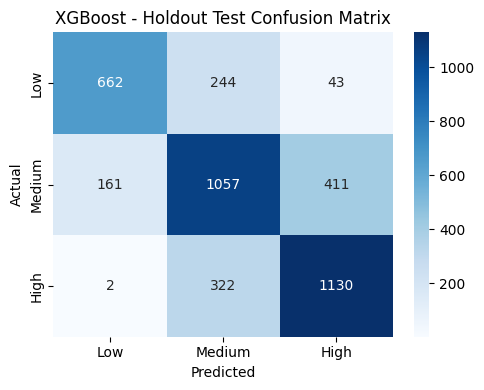

In [ ]:
# @title Final XGBoost Evaluation

final_xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.0174343284636044,
    subsample=0.8241012917547152,
    colsample_bytree=0.9664257554031433,
    random_state=42,
    n_jobs=-1,
    min_child_weight=5,
    gamma=0.38090753755782714,
    reg_alpha=0.34396851738504425,
    reg_lambda=0.8321364740856627
    #best parameters from optuna
)

final_xgb_model.fit(X, y)
xgb_y_pred = final_xgb_model.predict(X_test)

get_classification_metrics(y_test, xgb_y_pred, "XGBoost Final Evaluation")
xgb_metrics = evaluate_metrics(y_test, xgb_y_pred)

print("\nSummary")
for k, v in xgb_metrics.items():
    print(f"{k}: {v:.4f}")

# Confusion matrix
xgb_cm = confusion_matrix(y_test, xgb_y_pred, labels=[0, 1, 2])

plt.figure(figsize=(5, 4))
sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost - Holdout Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
#save metrics as df
metrics_df = pd.DataFrame([xgb_metrics], index=["XGBoost"])
metrics_df

,Accuracy,Precision,Recall,F1 Score
XGBoost,0.706597,0.709243,0.706597,0.706565


In [ ]:
#save and download XGBoost model
import joblib
joblib.dump(final_xgb_model, '/content/drive/MyDrive/Thesis/Models/XGBoost.pkl')

#download or load XGBoost model
#files.download('XGBoost.pkl')
#xgb_model = joblib.load("/content/drive/MyDrive/Thesis/Models/XGBoost.pkl")

['/content/drive/MyDrive/Thesis/Models/XGBoost.pkl']


  Random Forest Final Evaluation — CLASSIFICATION METRICS
  Accuracy  : 0.6935  (69.35%)
  Precision : 0.6943
  Recall    : 0.6935
  F1 Score  : 0.6936

Detailed Report:
              precision    recall  f1-score   support

         Low       0.77      0.72      0.75       949
      Medium       0.63      0.63      0.63      1629
        High       0.71      0.74      0.73      1454

    accuracy                           0.69      4032
   macro avg       0.71      0.70      0.70      4032
weighted avg       0.69      0.69      0.69      4032


Summary
Accuracy: 0.6935
Precision: 0.6943
Recall: 0.6935
F1 Score: 0.6936


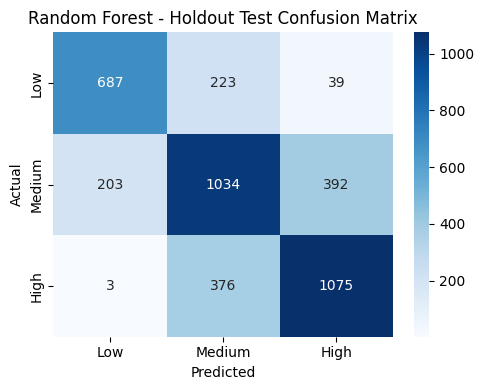

In [ ]:
# @title Final Random Forest Evaluation

final_rf_model = RandomForestClassifier(
          n_estimators  = 800,
          max_depth     = None,
          max_features  = 'sqrt',
          min_samples_split = 5,
          min_samples_leaf  = 2,
          class_weight  = 'balanced',
          random_state  = 42,
          n_jobs        = -1,
          max_samples = 0.6031451318469092
    )

final_rf_model.fit(X, y)
rf_y_pred = final_rf_model.predict(X_test)

get_classification_metrics(y_test, rf_y_pred, "Random Forest Final Evaluation")
rf_metrics = evaluate_metrics(y_test, rf_y_pred)

print("\nSummary")
for k, v in rf_metrics.items():
    print(f"{k}: {v:.4f}")

# Confusion matrix
rf_cm = confusion_matrix(y_test, rf_y_pred, labels=[0, 1, 2])

plt.figure(figsize=(5, 4))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Holdout Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
add_metrics = pd.DataFrame([rf_metrics], index=["Random Forest"])
metrics_df = pd.concat([metrics_df, add_metrics], ignore_index=False)
metrics_df

,Accuracy,Precision,Recall,F1 Score
XGBoost,0.706597,0.709243,0.706597,0.706565
Random Forest,0.693452,0.694303,0.693452,0.693634


In [ ]:
#save and download Random Forest model
import joblib
joblib.dump(final_rf_model, '/content/drive/MyDrive/Thesis/Models/Random_Forest.pkl')

#download or load Random Forest model
#files.download('Random_Forest.pkl')
#rf_model = joblib.load("/content/drive/MyDrive/Thesis/Models/Random_Forest.pkl")

['/content/drive/MyDrive/Thesis/Models/Random_Forest.pkl']

Training shape: (93452, 10)
Holdout shape : (4032, 10)
Training sequences: (93380, 72, 10)
Testing sequences : (4032, 72, 10)
Class Weights: {np.int64(0): np.float64(1.0661277800611957), np.int64(1): np.float64(0.7728149233226572), np.int64(2): np.float64(1.3019896543550704)}
Epoch 1/100
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.5882 - loss: 0.8133 - val_accuracy: 0.6724 - val_loss: 0.7283
Epoch 2/100
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.6466 - loss: 0.7271 - val_accuracy: 0.6845 - val_loss: 0.6885
Epoch 3/100
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.6563 - loss: 0.7120 - val_accuracy: 0.7121 - val_loss: 0.6717
Epoch 4/100
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.6566 - loss: 0.7032 - val_accuracy: 0.7069 - val_loss: 0.6653
Epoch 5/100
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.6586 - loss: 0.6968 - val_accuracy: 0.7072 - val_loss: 0.6687
Epoch 6/100
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step -

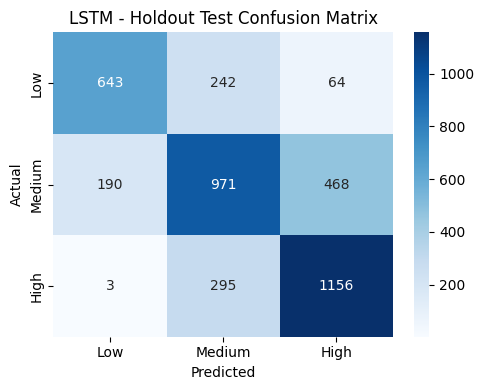

In [ ]:
# @title Final LSTM Evaluation

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Reproducibility
tf.keras.utils.set_random_seed(1)
tf.config.experimental.enable_op_determinism()

# Sequence builder
def create_sequences(data, targets, window_size):
    X_seq, y_seq = [], []

    for i in range(len(data) - window_size):
        X_seq.append(data[i:i + window_size])
        y_seq.append(targets[i + window_size])

    return np.array(X_seq), np.array(y_seq)

# Tuned LSTM model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),

        # First LSTM
        LSTM(
            units=128,
            return_sequences=True,
            kernel_regularizer=l2(1e-6)
        ),
        Dropout(0.5),

        # Second LSTM
        LSTM(
            units=56,
            return_sequences=False,
            kernel_regularizer=l2(1e-6)
        ),
        Dropout(0.5),

        # Dense layer
        Dense(
            units=64,
            activation='relu'
        ),
        Dropout(0.0),

        # Output layer
        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Feature Selection

selected_features = [
    "Hour",
    "soil_temperature_0_to_7cm (°C)",
    "temperature_2m (°C)",
    "Driving Direction",
    "apparent_temperature (°C)",
    "soil_temperature_7_to_28cm (°C)",
    "surface_pressure (hPa)",
    "vapour_pressure_deficit (kPa)",
    "DayOfYear",
    "Minute"
]

X_train = X[selected_features].copy()
X_holdout = X_test[selected_features].copy()

print("Training shape:", X_train.shape)
print("Holdout shape :", X_holdout.shape)

# Scale Features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_holdout_scaled = scaler.transform(X_holdout)


# Create Sequences

WINDOW = 72

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y.values,
    WINDOW
)

# Create Hold-out Sequences

combined_X = np.concatenate([
    X_train_scaled[-WINDOW:],
    X_holdout_scaled
])

combined_y = np.concatenate([
    y.values[-WINDOW:],
    y_test.values
])

X_test_seq, y_test_seq = create_sequences(
    combined_X,
    combined_y,
    WINDOW
)

assert len(X_test_seq) == len(y_test)
assert np.array_equal(y_test_seq, y_test.values)

print("Training sequences:", X_train_seq.shape)
print("Testing sequences :", X_test_seq.shape)

# Class Weights
classes = np.unique(y_train_seq)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_seq
)

class_weights = dict(zip(classes, weights))

print("Class Weights:", class_weights)


# Build Final Model

final_lstm_model = build_lstm_model(
    input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
)

# Early Stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=0.001,
    restore_best_weights=True
)

# Train Final Model
history = final_lstm_model.fit(

    X_train_seq,
    y_train_seq,

    validation_split=0.10,

    epochs=100,

    batch_size=64,

    class_weight=class_weights,

    callbacks=[early_stop],

    shuffle=False,

    verbose=1
)

# Hold-out Prediction
y_pred_prob = final_lstm_model.predict(X_test_seq, verbose=0)

lstm_y_pred = np.argmax(y_pred_prob, axis=1)

# Metrics
get_classification_metrics(
    y_test_seq,
    lstm_y_pred,
    "LSTM Final Evaluation"
)

lstm_metrics = evaluate_metrics(
    y_test_seq,
    lstm_y_pred
)

print("\nSummary")

for k, v in lstm_metrics.items():
    print(f"{k}: {v:.4f}")


# Confusion Matrix
lstm_cm = confusion_matrix(
    y_test_seq,
    lstm_y_pred,
    labels=[0, 1, 2]
)

plt.figure(figsize=(5,4))

sns.heatmap(
    lstm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM - Holdout Test Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
add_metrics = pd.DataFrame([lstm_metrics], index=["LSTM"])
metrics_df = pd.concat([metrics_df, add_metrics], ignore_index=False)
metrics_df

,Accuracy,Precision,Recall,F1 Score
XGBoost,0.706597,0.709243,0.706597,0.706565
Random Forest,0.693452,0.694303,0.693452,0.693634
LSTM,0.687004,0.688138,0.687004,0.685036


In [ ]:
#save and download LSTM model
import joblib
joblib.dump(final_lstm_model, '/content/drive/MyDrive/Thesis/Models/LSTM.pkl')

#download or load LSTM model
#files.download('LSTM.pkl')
#lstm_model = joblib.load("/content/drive/MyDrive/Thesis/Models/LSTM.pkl")

['/content/drive/MyDrive/Thesis/Models/LSTM.pkl']

In [ ]:
#save metrics_df
joblib.dump(metrics_df, 'metrics_df.pkl')
metrics_df.to_csv("metrics_df.csv", index=True, index_label="Model")

from google.colab import files
files.download("metrics_df.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>